In [ ]:
# --- CAI DAT THU VIEN ---
!pip install -q duckdb
!pip install -q tensorflow-recommenders
!pip install -q faiss-cpu
!pip install -q lightgbm
!pip install -q sentence-transformers

# --- KHAI BAO THU VIEN TOAN HE THONG ---
import os
import json
import requests
import numpy as np
import pandas as pd
import duckdb
import scipy.special

# Set environment variable to use Legacy Keras for tensorflow-recommenders compatibility
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# Thu vien Deep Learning & Recommendation
import tensorflow as tf
import tensorflow_recommenders as tfrs

# Thu vien Vector Search & Machine Learning
import faiss
import lightgbm as lgb
from sentence_transformers import SentenceTransformer

# Ket noi Google Drive de doc/ghi file
from google.colab import drive
drive.mount('/content/drive')

print("Da cai dat va load toan bo thu vien thanh cong!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.6 MB/s eta 0:00:00
Mounted at /content/drive
Da cai dat va load toan bo thu vien thanh cong!


Tien xu ly du lieu

In [ ]:
# --- SETUP THU MUC VA KHOI TAO DUCKDB ---
import os
import shutil
import duckdb

DRIVE_BASE_PATH = '/content/drive/MyDrive/steam/steam_100M'
LOCAL_BASE_PATH = '/content/steam_local_temp'

DRIVE_REVIEWS_DIR = f'{DRIVE_BASE_PATH}/reviews/reviews'
LOCAL_REVIEWS_DIR = f'{LOCAL_BASE_PATH}/reviews'
DRIVE_OUTPUT_DIR = f'{DRIVE_BASE_PATH}/processed_data'

# Tao thu muc output neu chua co
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

print("Kiem tra du lieu tren o cung ao Colab...")
if not os.path.exists(LOCAL_REVIEWS_DIR):
    print("Dang copy du lieu tu Drive vao Colab de xu ly an toan...")
    shutil.copytree(DRIVE_REVIEWS_DIR, LOCAL_REVIEWS_DIR, dirs_exist_ok=True)
    print("Copy hoan tat.")
else:
    print("Du lieu da san sang tren Colab.")

print("Khoi tao DuckDB...")
con = duckdb.connect(database=':memory:')
con.execute("PRAGMA temp_directory='/content/duckdb_temp'")
con.execute("PRAGMA memory_limit='10GB'")
con.execute("PRAGMA threads=4")

Kiem tra du lieu tren o cung ao Colab...
Du lieu da san sang tren Colab.
Khoi tao DuckDB...


In [ ]:
# --- CLEAN REVIEWS & CORE INTERACTIONS ---
print("Dang xu ly Phien 1: Ma tran tuong tac va lam sach...")
clean_reviews_path = f'{DRIVE_OUTPUT_DIR}/clean_reviews.parquet'
core_matrix_path = f'{DRIVE_OUTPUT_DIR}/core_interactions.parquet'

# 1. Tao file clean_reviews.parquet
sql_clean = f"""
COPY (
    WITH UserCounts AS (
        SELECT author_id, COUNT(*) as u_count FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet') GROUP BY author_id HAVING u_count >= 5
    ),
    GameCounts AS (
        SELECT appid, COUNT(*) as g_count FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet') GROUP BY appid HAVING g_count >= 50
    )
    SELECT
        r.author_id,
        r.appid,
        CAST(r.voted_up AS INTEGER) as voted_up_int,
        r.playtime_forever,
        (CAST(r.voted_up AS INTEGER) * 2) + LOG10(r.playtime_forever + 1) AS interaction_score
    FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet') r
    INNER JOIN UserCounts u ON r.author_id = u.author_id
    INNER JOIN GameCounts g ON r.appid = g.appid
) TO '{clean_reviews_path}' (FORMAT PARQUET);
"""
con.execute(sql_clean)
print(f"Da tao thanh cong: {clean_reviews_path}")

# 2. Tao file core_interactions.parquet (Co them cot thoi gian de chia tap Train/Test)
sql_core = f"""
COPY (
    SELECT
        r.author_id,
        r.appid,
        CAST(r.voted_up AS INTEGER) as voted_up_int,
        r.playtime_forever,
        r.timestamp_created,
        r.last_played,
        (CAST(r.voted_up AS INTEGER) * 2) + LOG10(r.playtime_forever + 1) AS interaction_score
    FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet') r
    WHERE author_id IN (SELECT DISTINCT author_id FROM read_parquet('{clean_reviews_path}'))
      AND appid IN (SELECT DISTINCT appid FROM read_parquet('{clean_reviews_path}'))
) TO '{core_matrix_path}' (FORMAT PARQUET);
"""
con.execute(sql_core)
print(f"Da tao thanh cong: {core_matrix_path}")

In [ ]:
# --- DAC TRUNG NGUOI DUNG (USER FEATURES) ---
print("Dang xu ly Phien 2 (Toi uu hoa RAM): User Feature Store...")
user_features_path = f'{DRIVE_OUTPUT_DIR}/user_features_full.parquet'

# Ep DuckDB xa du lieu ra o cung som hon de tranh bi he dieu hanh Colab kill
con.execute("PRAGMA memory_limit='6GB'")

sql_user = f"""
COPY (
    SELECT
        author_id,
        COUNT(*) as total_reviews_written,
        MAX(num_games_owned) as max_games_owned,
        MAX(num_reviews) as total_lifetime_reviews,
        AVG(playtime_forever) as avg_playtime_all_games,
        AVG(playtime_at_review) as avg_playtime_before_review,
        AVG(CAST(steam_purchase AS INTEGER)) as steam_purchase_ratio,
        AVG(CAST(primarily_steam_deck AS INTEGER)) as deck_usage_ratio,
        SUM(votes_up) as total_community_agreements,
        ANY_VALUE(language) as primary_language
    FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet')
    GROUP BY author_id
) TO '{user_features_path}' (FORMAT PARQUET);
"""

try:
    con.execute(sql_user)
    print(f"Xong Phien 2! Da luu tai: {user_features_path}")
except Exception as e:
    print(f"Co loi xay ra: {e}")

# Tra lai limit 10GB cho cac phien sau
con.execute("PRAGMA memory_limit='10GB'")

In [ ]:
# --- DAC TRUNG TRO CHOI (GAME FEATURES) ---
print("Dang xu ly Phien 3: Game Feature Store...")
game_features_path = f'{DRIVE_OUTPUT_DIR}/game_features_full.parquet'

sql_game = f"""
COPY (
    SELECT
        appid,
        COUNT(*) as total_reviews,
        AVG(CAST(voted_up AS INTEGER)) as positive_review_ratio,
        AVG(weighted_vote_score) as avg_weighted_score,
        SUM(comment_count) as total_discussion_comments,
        AVG(CAST(written_during_early_access AS INTEGER)) as early_access_player_ratio,
        AVG(playtime_forever) as global_avg_playtime
    FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet')
    GROUP BY appid
) TO '{game_features_path}' (FORMAT PARQUET);
"""

con.execute(sql_game)
print(f"Xong Phien 3! Da luu tai: {game_features_path}")

In [ ]:
# --- TRICH XUAT VAN BAN (TEXT EXTRACTION) ---
print("Dang xu ly Phien 4: Text Data Extraction...")
text_data_path = f'{DRIVE_OUTPUT_DIR}/reviews_text_only.parquet'

sql_text = f"""
COPY (
    SELECT
        rec_id,
        author_id,
        appid,
        CAST(voted_up AS INTEGER) as voted_up,
        review
    FROM read_parquet('{LOCAL_REVIEWS_DIR}/*.parquet')
    WHERE review IS NOT NULL AND LENGTH(review) > 10
) TO '{text_data_path}' (FORMAT PARQUET);
"""

con.execute(sql_text)
print(f"Xong Phien 4! Da luu tai: {text_data_path}")

In [ ]:
# --- NANG CAP DAC TRUNG TRO CHOI (GAME FEATURES ENHANCED) ---
print("Dang xu ly Phien 5: Game Features Enhanced...")

text_data_path = f'{DRIVE_OUTPUT_DIR}/reviews_text_only.parquet'
game_features_path = f'{DRIVE_OUTPUT_DIR}/game_features_full.parquet'
enhanced_features_path = f'{DRIVE_OUTPUT_DIR}/game_features_enhanced.parquet'

sql_enhanced = f"""
    COPY (
        WITH TextStats AS (
            SELECT
                appid,
                AVG(LENGTH(review)) as avg_review_length,
                SUM(CASE WHEN LENGTH(review) > 250 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) as deep_review_ratio
            FROM read_parquet('{text_data_path}')
            WHERE review IS NOT NULL
            GROUP BY appid
        )
        SELECT
            g.*,
            COALESCE(t.avg_review_length, 0) as avg_review_length,
            COALESCE(t.deep_review_ratio, 0.0) as deep_review_ratio
        FROM read_parquet('{game_features_path}') g
        LEFT JOIN TextStats t ON g.appid = t.appid
    ) TO '{enhanced_features_path}' (FORMAT PARQUET);
"""

con.execute(sql_enhanced)
print(f"Xong Phien 5! Da luu file nang cap tai: {enhanced_features_path}")

In [ ]:
# --- CAO DU LIEU STEAM API (METADATA CRAWLER) ---
import time
import json
import requests
import pandas as pd

API_OUTPUT_DIR = f'{DRIVE_OUTPUT_DIR}/game_metadata'
FINAL_GAME_FEATURES_PATH = f'{DRIVE_OUTPUT_DIR}/game_features_api.parquet'
os.makedirs(API_OUTPUT_DIR, exist_ok=True)

print("Dang lay danh sach AppID tu du lieu da lam sach...")
unique_appids_df = con.execute(f"SELECT DISTINCT appid FROM read_parquet('{core_matrix_path}')").df()
appids_to_fetch = unique_appids_df['appid'].tolist()
print(f"Tong so game can lay thong tin: {len(appids_to_fetch)}")

def fetch_steam_app_details(appid):
    url = f"https://store.steampowered.com/api/appdetails?appids={appid}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 429:
            print("Bip chan (Rate Limit 429). Dang doi 60 giay...")
            time.sleep(60)
            return fetch_steam_app_details(appid)

        if response.status_code == 200:
            data = response.json()
            str_appid = str(appid)
            if data and str_appid in data and data[str_appid].get('success'):
                game_data = data[str_appid]['data']
                genres = [g['description'] for g in game_data.get('genres', [])]
                categories = [c['description'] for c in game_data.get('categories', [])]

                return {
                    "appid": appid,
                    "name": game_data.get('name', ''),
                    "is_free": game_data.get('is_free', False),
                    "developer": game_data.get('developers', [''])[0] if game_data.get('developers') else '',
                    "genres": ", ".join(genres),
                    "categories": ", ".join(categories),
                    "release_date": game_data.get('release_date', {}).get('date', '')
                }
    except Exception:
        pass
    return None

checkpoint_file = f'{API_OUTPUT_DIR}/checkpoint.json'
fetched_data = {}

if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'r', encoding='utf-8') as f:
        fetched_data = json.load(f)
    print(f"Da phuc hoi {len(fetched_data)} games tu checkpoint.")

print("Bat dau keo du lieu tu Steam API...")
count = 0
for appid in appids_to_fetch:
    str_appid = str(appid)
    if str_appid in fetched_data:
        continue

    result = fetch_steam_app_details(appid)
    if result:
        fetched_data[str_appid] = result

    count += 1
    time.sleep(1.5)

    if count % 100 == 0:
        with open(checkpoint_file, 'w', encoding='utf-8') as f:
            json.dump(fetched_data, f, ensure_ascii=False)
        print(f"Da xu ly {count} games. Dang luu tam...")

with open(checkpoint_file, 'w', encoding='utf-8') as f:
    json.dump(fetched_data, f, ensure_ascii=False)

print("Hoan tat keo API. Dang luu thanh file Parquet...")
final_df = pd.DataFrame(list(fetched_data.values()))
final_df.to_parquet(FINAL_GAME_FEATURES_PATH, index=False)
print(f"Thanh cong! Tinh nang cua game da duoc luu tai: {FINAL_GAME_FEATURES_PATH}")

In [ ]:
import duckdb
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import gc

BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
TEXT_PATH = f'{BASE_PATH}/reviews_text_only.parquet'
API_PATH = f'{BASE_PATH}/game_features_api.parquet'
ENRICHED_API_PATH = f'{BASE_PATH}/game_features_api_enriched.parquet'

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text) # Chi giu lai chu cai
    return text

print("1. Khoi tao DB (Che do Random Sampling)...")
con = duckdb.connect()

# Gioi han RAM an toan o muc 6GB
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA threads=2")

print("2. Dang quet du lieu (Dang ap dung Random Sampling chong tran RAM)...")
# Dùng `random() < 0.02` để chỉ lấy ngẫu nhiên 2% dữ liệu trên toàn hệ thống (khoảng 2 triệu review).
# Việc này bỏ qua hoàn toàn bước tạo Hash Table của ROW_NUMBER, giúp RAM chạy cực nhẹ.
query = f"""
    SELECT
        CAST(appid AS VARCHAR) as appid,
        STRING_AGG(SUBSTRING(review, 1, 250), ' ') as all_reviews
    FROM read_parquet('{TEXT_PATH}')
    WHERE review IS NOT NULL
      AND LENGTH(review) > 40
      AND random() < 0.02
    GROUP BY appid
"""
df_texts = con.execute(query).df()

print(f"Da lay xong du lieu text ngau nhien cua {len(df_texts)} games. Dang lam sach...")
df_texts['cleaned_reviews'] = df_texts['all_reviews'].apply(clean_text)

# QUAN LY BO NHO THU CONG: Xoa ngay cot text tho de giai phong RAM
df_texts = df_texts.drop(columns=['all_reviews'])
gc.collect()

print("3. Dang chay thuat toan TF-IDF de trich xuat Top 15 tu khoa...")
# Chay TF-IDF tren tap du lieu da duoc lay mau
vectorizer = TfidfVectorizer(max_df=0.8, min_df=3, stop_words='english', max_features=3000)
tfidf_matrix = vectorizer.fit_transform(df_texts['cleaned_reviews'])
feature_names = vectorizer.get_feature_names_out()

top_keywords_list = []
for i in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix.getrow(i)
    if row.nnz > 0:
        # Lay 15 tu khoa quan trong nhat
        top_indices = row.indices[row.data.argsort()[-15:][::-1]]
        top_words = [feature_names[idx] for idx in top_indices]
        top_keywords_list.append(" ".join(top_words))
    else:
        top_keywords_list.append("")

df_texts['review_keywords'] = top_keywords_list

# Giai phong memory ma tran TF-IDF
del tfidf_matrix
del vectorizer
df_texts = df_texts.drop(columns=['cleaned_reviews'])
gc.collect()

print("4. Dang ghep Tu khoa vao bang Game API goc...")
df_api = pd.read_parquet(API_PATH)
df_api['appid'] = df_api['appid'].astype(str)

df_final = pd.merge(df_api, df_texts[['appid', 'review_keywords']], on='appid', how='left')
df_final['review_keywords'] = df_final['review_keywords'].fillna('')

# Luu thanh file API Enriched (Da duoc nang cap)
df_final.to_parquet(ENRICHED_API_PATH, index=False)

print(f"Thanh cong ruc ro! Da luu file moi tai: {ENRICHED_API_PATH}")
print(df_final[['name', 'review_keywords']].head())

1. Khoi tao DB (Che do Random Sampling)...
2. Dang quet du lieu (Dang ap dung Random Sampling chong tran RAM)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Da lay xong du lieu text ngau nhien cua 32075 games. Dang lam sach...
3. Dang chay thuat toan TF-IDF de trich xuat Top 15 tu khoa...
4. Dang ghep Tu khoa vao bang Game API goc...
Thanh cong ruc ro! Da luu file moi tai: /content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api_enriched.parquet
                     name                                    review_keywords
0    SUPER CHICKEN JUMPER  jogo que muito mas eu um bom para ele uma difc...
1            16bit Trader  city cute game want selling nen travel rules f...
2  Sid Meier’s Ace Patrol  ento game meu ele like pc fun jogo frequently ...
3                 英雄群侠传II  equipment launch terms completely save said pl...
4                ALICE VR  average puzzles just desktop scifi performance...


In [ ]:
import os

checkpoint_file = '/content/drive/MyDrive/steam/steam_100M/processed_data/game_metadata/checkpoint.json'

if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    print("Đã xóa sạch Checkpoint cũ! Hệ thống đã mất trí nhớ.")
else:
    print("Không tìm thấy file Checkpoint.")

Đã xóa sạch Checkpoint cũ! Hệ thống đã mất trí nhớ.


In [ ]:
# ====================================================================================
# HỆ THỐNG CÀO DỮ LIỆU STEAM
# ====================================================================================

import os
import time
import json
import requests
import pandas as pd
import threading
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
import duckdb
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import gc

try:
    from tqdm.notebook import tqdm
except ImportError:
    !pip install tqdm
    from tqdm.notebook import tqdm

print("="*100)
print("KHỞI ĐỘNG CỖ MÁY CÀO DATA (BẢO TOÀN 100% SỐ LƯỢNG GAME)".center(100))
print("="*100)

DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/steam/steam_100M/processed_data'
core_matrix_path = f'{DRIVE_OUTPUT_DIR}/core_interactions.parquet'
API_OUTPUT_DIR = f'{DRIVE_OUTPUT_DIR}/game_metadata'
FINAL_GAME_FEATURES_PATH = f'{DRIVE_OUTPUT_DIR}/game_features_api.parquet'
os.makedirs(API_OUTPUT_DIR, exist_ok=True)

con = duckdb.connect()
print("1. Đang lấy danh sách AppID từ dữ liệu đã làm sạch...")
unique_appids_df = con.execute(f"SELECT DISTINCT appid FROM read_parquet('{core_matrix_path}')").df()
appids_to_fetch = unique_appids_df['appid'].tolist()
print(f"Tổng số game cần cào: {len(appids_to_fetch)}")

thread_local = threading.local()

def get_session():
    if not hasattr(thread_local, "session"):
        thread_local.session = requests.Session()
        thread_local.session.headers.update({
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/124.0.0.0'
        })
    return thread_local.session

# --- HÀM WORKER: CÀO API VÀ HTML (BẢO VỆ CHỐNG BLOCK IP) ---
def fetch_full_steam_details(appid):
    session = get_session()
    str_appid = str(appid)
    # Gán tên mặc định để nếu bị lỗi mạng/game bị xóa, hệ thống KHÔNG bỏ qua game này
    result = {
        "appid": str_appid, "name": f"Unknown Game {str_appid}", "is_free": False,
        "developer": "", "genres": "", "categories": "", "release_date": ""
    }

    # BƯỚC 1: LẤY JSON API (CÓ XỬ LÝ CHỐNG BLOCK)
    api_retry = 0
    while api_retry < 3:
        try:
            api_url = f"https://store.steampowered.com/api/appdetails?appids={appid}&cc=us&l=english"
            resp = session.get(api_url, timeout=7)
            if resp.status_code == 429: # Nếu API quá tải
                time.sleep(5)
                api_retry += 1
                continue
            if resp.status_code == 200:
                data = resp.json()
                if data and str_appid in data and data[str_appid].get('success'):
                    game_data = data[str_appid]['data']
                    result['name'] = game_data.get('name', result['name'])
                    result['is_free'] = game_data.get('is_free', False)
                    result['developer'] = game_data.get('developers', [''])[0] if game_data.get('developers') else ''
                    if 'genres' in game_data:
                        result['genres'] = ", ".join([g['description'] for g in game_data['genres']])
            break
        except:
            api_retry += 1
            time.sleep(2)

    # BƯỚC 2: LẤY 20 TAGS HTML
    html_url = f"https://store.steampowered.com/app/{appid}"
    html_retry = 0
    while html_retry < 3:
        try:
            h_resp = session.get(html_url, timeout=7)
            if h_resp.status_code == 429:
                time.sleep(3)
                html_retry += 1
                continue
            if h_resp.status_code == 200:
                soup = BeautifulSoup(h_resp.text, 'html.parser')
                tag_elems = soup.find_all('a', class_='app_tag')
                if tag_elems:
                    tags = [t.text.strip() for t in tag_elems if t.text.strip() != '+']
                    result['categories'] = ", ".join(tags[:20])
            break
        except:
            html_retry += 1
            time.sleep(1)

    return str_appid, result

# --- QUẢN LÝ CHECKPOINT & THỰC THI ĐA LUỒNG ---
checkpoint_file = f'{API_OUTPUT_DIR}/checkpoint.json'
fetched_data = {}

# [LƯU Ý]: Nếu bạn chưa xóa file checkpoint cũ, hãy mở file trình duyệt Drive xóa nó đi
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'r', encoding='utf-8') as f:
        fetched_data = json.load(f)
    print(f"Đã phục hồi {len(fetched_data)} games từ checkpoint.")

pending_appids = [aid for aid in appids_to_fetch if str(aid) not in fetched_data]

if pending_appids:
    # Hạ số luồng xuống 15 để tránh làm sập Steam API
    print(f"2. Bắt đầu cào {len(pending_appids)} game bằng 15 luồng an toàn...")
    count = 0

    with ThreadPoolExecutor(max_workers=15) as executor:
        futures = {executor.submit(fetch_full_steam_details, aid): aid for aid in pending_appids}

        for future in tqdm(as_completed(futures), total=len(pending_appids), desc="Đang tải HTML & API"):
            aid_str, data_res = future.result()

            # [VÁ LỖI]: Bỏ điều kiện if data_res['name'] == True. Cứ cào được là lưu!
            fetched_data[aid_str] = data_res

            count += 1
            if count % 500 == 0:
                with open(checkpoint_file, 'w', encoding='utf-8') as f:
                    json.dump(fetched_data, f, ensure_ascii=False)

    with open(checkpoint_file, 'w', encoding='utf-8') as f:
        json.dump(fetched_data, f, ensure_ascii=False)

print("3. Hoàn tất cào. Đang lưu thành file Parquet gốc...")
final_df = pd.DataFrame(list(fetched_data.values()))
final_df['appid'] = final_df['appid'].astype(str)
final_df.to_parquet(FINAL_GAME_FEATURES_PATH, index=False)
print(f"Đã lưu tại: {FINAL_GAME_FEATURES_PATH}")


# ====================================================================================
# PHẦN 2: THUẬT TOÁN TF-IDF RANDOM SAMPLING
# ====================================================================================

BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
TEXT_PATH = f'{BASE_PATH}/reviews_text_only.parquet'
API_PATH = FINAL_GAME_FEATURES_PATH
ENRICHED_API_PATH = f'{BASE_PATH}/game_features_api_enriched.parquet'

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z ]', '', text)
    return text

print("\n4. Khởi tạo DB (Chế độ Random Sampling để chống tràn RAM)...")
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA threads=2")

print("5. Đang quét 2% dữ liệu Text (Sampling)...")
query = f"""
    SELECT CAST(appid AS VARCHAR) as appid, STRING_AGG(SUBSTRING(review, 1, 250), ' ') as all_reviews
    FROM read_parquet('{TEXT_PATH}')
    WHERE review IS NOT NULL AND LENGTH(review) > 40 AND random() < 0.02
    GROUP BY appid
"""
df_texts = con.execute(query).df()

print(f"Đã lấy xong Text của {len(df_texts)} games. Đang làm sạch...")
df_texts['cleaned_reviews'] = df_texts['all_reviews'].apply(clean_text)
df_texts = df_texts.drop(columns=['all_reviews'])
gc.collect()

print("6. Đang chạy thuật toán TF-IDF trích xuất Top 15 từ khóa...")
vectorizer = TfidfVectorizer(max_df=0.8, min_df=3, stop_words='english', max_features=3000)
tfidf_matrix = vectorizer.fit_transform(df_texts['cleaned_reviews'])
feature_names = vectorizer.get_feature_names_out()

top_keywords_list = []
for i in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix.getrow(i)
    if row.nnz > 0:
        top_indices = row.indices[row.data.argsort()[-15:][::-1]]
        top_words = [feature_names[idx] for idx in top_indices]
        top_keywords_list.append(" ".join(top_words))
    else:
        top_keywords_list.append("")

df_texts['review_keywords'] = top_keywords_list

del tfidf_matrix, vectorizer; gc.collect()
df_texts = df_texts.drop(columns=['cleaned_reviews']); gc.collect()

print("7. Đang ghép Từ khóa vào bảng Game API...")
df_api = pd.read_parquet(API_PATH)
df_api['appid'] = df_api['appid'].astype(str)

df_final = pd.merge(df_api, df_texts[['appid', 'review_keywords']], on='appid', how='left')
df_final['review_keywords'] = df_final['review_keywords'].fillna('')

df_final.to_parquet(ENRICHED_API_PATH, index=False)

print("\n" + "="*80)
print(f"BẢO TOÀN THÀNH CÔNG! DATABASE ĐÃ SẴN SÀNG TẠI:\n {ENRICHED_API_PATH}")
print("="*80)
print(df_final[['appid', 'name', 'categories']].head())

                      KHỞI ĐỘNG CỖ MÁY CÀO DATA (BẢO TOÀN 100% SỐ LƯỢNG GAME)                       
1. Đang lấy danh sách AppID từ dữ liệu đã làm sạch...
Tổng số game cần cào: 26367
2. Bắt đầu cào 26367 game bằng 15 luồng an toàn...


Đang tải HTML & API:   0%|          | 0/26367 [00:00<?, ?it/s]

3. Hoàn tất cào. Đang lưu thành file Parquet gốc...
Đã lưu tại: /content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api.parquet

4. Khởi tạo DB (Chế độ Random Sampling để chống tràn RAM)...
5. Đang quét 2% dữ liệu Text (Sampling)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Đã lấy xong Text của 32119 games. Đang làm sạch...
6. Đang chạy thuật toán TF-IDF trích xuất Top 15 từ khóa...
7. Đang ghép Từ khóa vào bảng Game API...

BẢO TOÀN THÀNH CÔNG! DATABASE ĐÃ SẴN SÀNG TẠI:
 /content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api_enriched.parquet
     appid                       name  \
0    73190           Pride of Nations   
1  1302780       Zombo Buster Advance   
2  1720850                        A=B   
3   980830  Spirit Hunter: Death Mark   
4  2969380                     BAKERU   

                                          categories  
0  Strategy, Simulation, Grand Strategy, Historic...  
1  Strategy, Indie, Tower Defense, Zombies, Singl...  
2  Puzzle, Programming, Education, Casual, Text-B...  
3  Adventure, Horror, Visual Novel, Violent, Anim...  
4  Action, Adventure, Action-Adventure, 3D Platfo...  


In [ ]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

try:
    from tqdm.notebook import tqdm
except ImportError:
    !pip install tqdm
    from tqdm.notebook import tqdm

print("="*90)
print("CHIẾN DỊCH 'HỒI SINH' TÊN GAME BỊ ẨN (3-TIER RESCUE)".center(90))
print("="*90)

FILE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api_enriched.parquet'

# 1. TẢI DỮ LIỆU
print("1. Đang nạp Database...")
df = pd.read_parquet(FILE_PATH)
df['appid'] = df['appid'].astype(str)

unknown_mask = df['name'].str.startswith('Unknown Game')
unknown_appids = df[unknown_mask]['appid'].tolist()

print(f"-> Phát hiện {len(unknown_appids)} game đang bị mất tên.")

if len(unknown_appids) == 0:
    print("Mọi game đều đã có tên! Không cần thực hiện thêm.")
else:
    recovered_names = {}

    # ==========================================================
    # LỚP 1: GLOBAL STEAM APP LIST
    # ==========================================================
    print("\n2. Kích hoạt Lớp 1: Quét danh sách Global Steam App List...")
    try:
        resp = requests.get("https://api.steampowered.com/ISteamApps/GetAppList/v2/", timeout=10)
        if resp.status_code == 200:
            app_list = resp.json().get('applist', {}).get('apps', [])
            global_dict = {str(app['appid']): app['name'] for app in app_list}

            for aid in unknown_appids:
                if aid in global_dict and global_dict[aid].strip():
                    recovered_names[aid] = global_dict[aid]
            print(f"   + Đã cứu được {len(recovered_names)} tên từ Global List.")
    except Exception as e:
        print(f"   - Lỗi Lớp 1: {e}")

    # ==========================================================
    # LỚP 2 & 3: STEAMSPY VÀ HTML SCRAPING (Cho những game cứng đầu)
    # ==========================================================
    remaining_appids = [aid for aid in unknown_appids if aid not in recovered_names]

    if remaining_appids:
        print(f"\n3. Kích hoạt Lớp 2 & 3: Dùng Đa luồng cào SteamSpy & HTML cho {len(remaining_appids)} game còn lại...")

        def rescue_hardcore_name(appid):
            # Thử SteamSpy trước (Tốt cho game đã bị gỡ)
            try:
                r = requests.get(f"https://steamspy.com/api.php?request=appdetails&appid={appid}", timeout=5)
                if r.status_code == 200:
                    data = r.json()
                    if 'name' in data and data['name']:
                        return appid, data['name']
            except: pass

            # Thử cào HTML Steam
            try:
                headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
                r = requests.get(f"https://store.steampowered.com/app/{appid}", headers=headers, timeout=5)
                if r.status_code == 200:
                    soup = BeautifulSoup(r.text, 'html.parser')
                    title_elem = soup.find('div', class_='apphub_AppName')
                    if title_elem:
                        return appid, title_elem.text.strip()
            except: pass

            return appid, None # Bó tay

        with ThreadPoolExecutor(max_workers=15) as executor:
            futures = {executor.submit(rescue_hardcore_name, aid): aid for aid in remaining_appids}
            for future in tqdm(as_completed(futures), total=len(remaining_appids), desc="Đang phá ngoặc"):
                aid, name = future.result()
                if name:
                    recovered_names[aid] = name

    # ==========================================================
    # CẬP NHẬT VÀ LƯU DATABASE
    # ==========================================================
    print(f"\n4. TỔNG KẾT: Đã cứu thành công {len(recovered_names)} / {len(unknown_appids)} game!")

    if recovered_names:
        print("Đang ghi đè tên thật vào Database...")

        def apply_new_name(row):
            aid = str(row['appid'])
            if aid in recovered_names:
                return recovered_names[aid]
            return row['name']

        df['name'] = df.apply(apply_new_name, axis=1)

        # Lưu đè lại file
        df.to_parquet(FILE_PATH, index=False)
        print(f"HOÀN TẤT! File đã được lưu bản sạch sẽ tại: {FILE_PATH}")

        # In thử vài game vừa được cứu
        print("\nVÀI CÁI TÊN VỪA ĐƯỢC ĐƯA RA ÁNH SÁNG:")
        rescue_df = df[df['appid'].isin(list(recovered_names.keys()))]
        with pd.option_context('display.max_colwidth', 100):
            display(rescue_df[['appid', 'name', 'categories']].sample(min(5, len(rescue_df))))

    else:
        print("Không có thêm tên nào được cứu. Những game này có thể đã bị Steam xóa sạch dữ liệu gốc.")

                   CHIẾN DỊCH 'HỒI SINH' TÊN GAME BỊ ẨN (3-TIER RESCUE)                   
1. Đang nạp Database...
-> Phát hiện 58 game đang bị mất tên.

2. Kích hoạt Lớp 1: Quét danh sách Global Steam App List...

3. Kích hoạt Lớp 2 & 3: Dùng Đa luồng cào SteamSpy & HTML cho 58 game còn lại...


Đang phá ngoặc:   0%|          | 0/58 [00:00<?, ?it/s]


4. TỔNG KẾT: Đã cứu thành công 0 / 58 game!
Không có thêm tên nào được cứu. Những game này có thể đã bị Steam xóa sạch dữ liệu gốc.


In [ ]:
# --- DON DEP BO NHO VA HOAN TAT ---
print(f"Dang kiem tra thu muc {LOCAL_BASE_PATH}...")
if os.path.exists(LOCAL_BASE_PATH):
    print("Phat hien thu muc tam. Dang xoa toan bo du lieu ben trong...")
    shutil.rmtree(LOCAL_BASE_PATH)
    print("Da xoa thanh cong! Dung luong o cung Colab da duoc giai phong.")
else:
    print("Thu muc khong ton tai. Khong can xoa.")

print("CHUC MUNG! TOAN BO QUY TRINH XU LY DU LIEU DA HOAN TAT CHINH XAC.")

kiem tra du lieu sau xu ly

In [ ]:
import os

def list_files_with_full_paths(base_path):
    print(f"Danh sach cau truc va duong dan chi tiet tai: {base_path}\n")
    print("=" * 70)

    if not os.path.exists(base_path):
        print("Loi: Khong tim thay thu muc. Vui long kiem tra lai duong dan.")
        return

    for root, dirs, files in os.walk(base_path):
        # In ra duong dan tuyet doi cua thu muc hien tai
        print(f"[Thu muc] {root}")

        for file in files:
            # Bo qua cac file he thong hoac cache cua Colab/Jupyter
            if file.startswith('.') or '.ipynb_checkpoints' in root:
                continue

            # Tao va in ra duong dan tuyet doi cua tung file
            full_path = os.path.join(root, file)
            print(f"    |-- [File] {full_path}")

        print("-" * 70)

# Thuc thi
TARGET_DIR = '/content/drive/MyDrive/steam/steam_100M/processed_data'
list_files_with_full_paths(TARGET_DIR)

Danh sach cau truc va duong dan chi tiet tai: /content/drive/MyDrive/steam/steam_100M/processed_data

[Thu muc] /content/drive/MyDrive/steam/steam_100M/processed_data
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/clean_reviews.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/core_interactions.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/game_features_full.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/reviews_text_only.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/user_features_full.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/game_features_enhanced.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/tmp_clean_reviews.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api.parquet
    |-- [File] /content/drive/MyDrive/steam/steam_100M/process

In [ ]:
import duckdb
import os
import pandas as pd

processed_data_path = '/content/drive/MyDrive/steam/steam_100M/processed_data'

print(f"DANG QUET SCHEMA CUA CAC FILE PARQUET TRONG: {processed_data_path}\n")
print("=" * 60)

if not os.path.exists(processed_data_path):
    print("Loi: Khong tim thay thu muc. Hay kiem tra lai duong dan Drive.")
else:
    for file in os.listdir(processed_data_path):
        if file.endswith('.parquet'):
            file_path = os.path.join(processed_data_path, file)
            print(f"\n[FILE] {file}")
            try:
                # Dung DuckDB de doc metadata cua Parquet thay vi load toan bo data
                query = f"DESCRIBE SELECT * FROM read_parquet('{file_path}')"
                df_schema = duckdb.execute(query).df()

                # In ra danh sach cot va kieu du lieu tuong ung
                for index, row in df_schema.iterrows():
                    column_name = row['column_name']
                    column_type = row['column_type']
                    print(f"  |-- {column_name} ({column_type})")

            except Exception as e:
                print(f"  |-- Loi doc file: {e}")

print("\n" + "=" * 60)
print("Hoan tat viec trich xuat Schema!")

DANG QUET SCHEMA CUA CAC FILE PARQUET TRONG: /content/drive/MyDrive/steam/steam_100M/processed_data


[FILE] clean_reviews.parquet
  |-- author_id (BIGINT)
  |-- appid (BIGINT)
  |-- voted_up_int (INTEGER)
  |-- playtime_forever (BIGINT)
  |-- interaction_score (DOUBLE)

[FILE] core_interactions.parquet
  |-- author_id (BIGINT)
  |-- appid (BIGINT)
  |-- voted_up_int (INTEGER)
  |-- playtime_forever (BIGINT)
  |-- timestamp_created (BIGINT)
  |-- last_played (BIGINT)
  |-- interaction_score (DOUBLE)

[FILE] game_features_full.parquet
  |-- appid (BIGINT)
  |-- total_reviews (BIGINT)
  |-- positive_review_ratio (DOUBLE)
  |-- avg_weighted_score (DOUBLE)
  |-- total_discussion_comments (DOUBLE)
  |-- early_access_player_ratio (DOUBLE)
  |-- global_avg_playtime (DOUBLE)

[FILE] reviews_text_only.parquet
  |-- rec_id (BIGINT)
  |-- author_id (BIGINT)
  |-- appid (BIGINT)
  |-- voted_up (INTEGER)
  |-- review (VARCHAR)

[FILE] user_features_full.parquet
  |-- author_id (BIGINT)
  |-- total_

In [ ]:
import pandas as pd
from IPython.display import display

# Đường dẫn chuẩn tới file Parquet
FILE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api_enriched.parquet'

print("="*80)
print("BÁO CÁO KIỂM KÊ CHẤT LƯỢNG DỮ LIỆU GAME (X-QUANG PARQUET)".center(80))
print("="*80)

try:
    # Đọc file vào DataFrame
    df = pd.read_parquet(FILE_PATH)

    print(f"\nĐã nạp thành công! Tổng số Game trong file: {len(df):,}")
    print(f"Tổng số Cột đặc trưng: {df.shape[1]}")

    print("\n" + "-"*80)
    print("1. CÁC CỘT DỮ LIỆU VÀ KIỂU DỮ LIỆU:")
    print("-"  *80)
    # df.info() in ra màn hình cấu trúc rất chi tiết
    df.info()

    print("\n" + "-"*80)
    print("2. KIỂM TRA DỮ LIỆU BỊ THIẾU (NULL/NaN):")
    print("-"  *80)
    missing_data = df.isna().sum()
    missing_data = missing_data[missing_data > 0]
    if missing_data.empty:
        print("Tuyệt vời! Không có bất kỳ ô dữ liệu nào bị trống (NaN).")
    else:
        print("Cảnh báo! Có các cột bị thiếu dữ liệu:")
        print(missing_data.to_string())

    print("\n" + "-"*80)
    print("3. THỐNG KÊ CHI TIẾT CÁC CỘT VĂN BẢN (Chứa Thể loại & Tag ngách):")
    print("-"  *80)
    # Lọc ra các cột là Text (object/string) để xem độ dài và sự đa dạng
    text_cols = df.select_dtypes(include=['object', 'string']).columns
    if len(text_cols) > 0:
        display(df[text_cols].describe())

    print("\n" + "-"*80)
    print("4. TRÍCH XUẤT 5 GAME MẪU (Tập trung vào Cột 'categories' và 'review_keywords'):")
    print("-"  *80)
    # Chọn ra các cột quan trọng nhất để hiển thị
    cols_to_show = [c for c in ['appid', 'name', 'genres', 'categories', 'review_keywords'] if c in df.columns]

    # Mở rộng giới hạn hiển thị chữ để đọc được trọn vẹn 20 tags
    with pd.option_context('display.max_colwidth', 200):
        display(df[cols_to_show].sample(5)) # Lấy ngẫu nhiên 5 game thay vì lấy từ trên xuống

except Exception as e:
    print(f"\nLỗi khi đọc file: {e}")
    print("Vui lòng kiểm tra lại xem file có thực sự tồn tại ở đường dẫn trên hay không.")

           BÁO CÁO KIỂM KÊ CHẤT LƯỢNG DỮ LIỆU GAME (X-QUANG PARQUET)            

Đã nạp thành công! Tổng số Game trong file: 26,367
Tổng số Cột đặc trưng: 8

--------------------------------------------------------------------------------
1. CÁC CỘT DỮ LIỆU VÀ KIỂU DỮ LIỆU:
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26367 entries, 0 to 26366
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   appid            26367 non-null  object
 1   name             26367 non-null  object
 2   is_free          26367 non-null  bool  
 3   developer        26367 non-null  object
 4   genres           26367 non-null  object
 5   categories       26367 non-null  object
 6   release_date     26367 non-null  object
 7   review_keywords  26367 non-null  object
dtypes: bool(1), object(7)
memory usage: 1.4+ MB

-----------------------------------

,appid,name,developer,genres,categories,release_date,review_keywords
count,26367,26367,26367,26367,26367,26367,26367
unique,26367,26322,7907,708,23501,1,20950
top,672150,F.E.A.R.,,,,,
freq,1,3,15112,15095,2377,26367,4963



--------------------------------------------------------------------------------
4. TRÍCH XUẤT 5 GAME MẪU (Tập trung vào Cột 'categories' và 'review_keywords'):
--------------------------------------------------------------------------------


,appid,name,genres,categories,review_keywords
12406,1724140,Craftomation 101: Programming & Craft,"Indie, Simulation, Strategy, Early Access","Education, Programming, Automation, Sandbox, Puzzle, Crafting, Robots, Base Building, Strategy, 2D, Cute, Singleplayer, Simulation, Indie, Early Access, Open World Survival Craft, Casual, Relaxing...",logic fun command generation shallow resource units love entirely built curve details balance learning tutorial
2835,1766420,Zero Chastity: A Sultry Summer Holiday,Adventure,,
11667,301690,Cobi Treasure Deluxe,,"Casual, Puzzle, Match 3",
15557,1566230,Turn on all the lights,,"Relaxing, Minimalist, Electronic, Puzzle, Short, Education, Family Friendly, Logic, Atmospheric, Abstract, Casual, Experimental, Singleplayer, Indie, 2D",little bad
19192,300060,ADR1FT,,"Space, Adventure, VR, Indie, First-Person, Walking Simulator, Survival, Singleplayer, Atmospheric, Simulation, Sci-fi, Female Protagonist",vr space game tech track intense stunning great really graphics better demo best playing feeling


In [ ]:
import pandas as pd

FILE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data/game_features_api_enriched.parquet'
df = pd.read_parquet(FILE_PATH)

# Lọc ra các game có tên bắt đầu bằng "Unknown Game"
unknown_df = df[df['name'].str.startswith('Unknown Game')]
total_unknown = len(unknown_df)

# Phân loại
has_tags = unknown_df[unknown_df['categories'].str.strip() != ""]
no_tags = unknown_df[unknown_df['categories'].str.strip() == ""]

print("="*80)
print("BÁO CÁO PHÂN TÍCH GAME BỊ ẨN/XÓA (UNKNOWN GAMES)".center(80))
print("="*80)

print(f"Tổng số game bị Steam ẩn thông tin API: {total_unknown:,} / {len(df):,} game ({total_unknown/len(df)*100:.2f}%)")
print(f"Số game cỗ máy HTML VƯỢT RÀO cứu được Tags: {len(has_tags):,} game")
print(f"Số game đã chết hoàn toàn (Không tên, Không Tag): {len(no_tags):,} game")

print("\n" + "-"*80)
print("5 GAME VƯỢT RÀO THÀNH CÔNG (MẤT TÊN NHƯNG VẪN CÒN LINH HỒN):")
print("-"  *80)
if len(has_tags) > 0:
    with pd.option_context('display.max_colwidth', 150):
        display(has_tags[['appid', 'name', 'categories']].sample(min(100, len(has_tags))))
else:
    print("Không có game nào.")

                BÁO CÁO PHÂN TÍCH GAME BỊ ẨN/XÓA (UNKNOWN GAMES)                
Tổng số game bị Steam ẩn thông tin API: 58 / 26,367 game (0.22%)
Số game cỗ máy HTML VƯỢT RÀO cứu được Tags: 0 game
Số game đã chết hoàn toàn (Không tên, Không Tag): 58 game

--------------------------------------------------------------------------------
5 GAME VƯỢT RÀO THÀNH CÔNG (MẤT TÊN NHƯNG VẪN CÒN LINH HỒN):
--------------------------------------------------------------------------------
Không có game nào.


train


In [ ]:
# ====================================================================================
# CELL 1: PREPARATION & TEMPORAL SPLITTING
# ====================================================================================

import duckdb
import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
MODEL_DIR = f'{BASE_PATH}/models'
os.makedirs(MODEL_DIR, exist_ok=True)

def create_temporal_splits(interaction_path):
    print("Bắt đầu chia tập dữ liệu theo thời gian (Temporal Split)...")
    con = duckdb.connect()

    # Chỉ lấy những user có ít nhất 5 tương tác để đảm bảo đủ data chia tập
    query = f"""
    WITH ranked_interactions AS (
        SELECT
            author_id, appid, interaction_score, timestamp_created,
            ROW_NUMBER() OVER(PARTITION BY author_id ORDER BY timestamp_created DESC) as reverse_chron_rank,
            COUNT(*) OVER(PARTITION BY author_id) as total_interactions
        FROM read_parquet('{interaction_path}')
    )
    SELECT * FROM ranked_interactions WHERE total_interactions >= 5
    """
    df_all = con.execute(query).df()

    # Rank 1 (Mới nhất) -> Test
    df_test = df_all[df_all['reverse_chron_rank'] == 1].copy()

    # Rank 2 (Mới thứ hai) -> Validation
    df_val = df_all[df_all['reverse_chron_rank'] == 2].copy()

    # Rank 3 trở đi (Quá khứ) -> Train
    df_train = df_all[df_all['reverse_chron_rank'] >= 3].copy()

    # Lưu ra Parquet để dùng cho các bước sau
    df_train.to_parquet(f'{BASE_PATH}/train_interactions.parquet')
    df_val.to_parquet(f'{BASE_PATH}/val_interactions.parquet')
    df_test.to_parquet(f'{BASE_PATH}/test_interactions.parquet')

    print(f"Hoàn tất! Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
    return df_train, df_val, df_test

# Thực thi
train_df, val_df, test_df = create_temporal_splits(f'{BASE_PATH}/core_interactions.parquet')

In [ ]:
# ====================================================================================
# CELL 2: TRAIN ADVANCED MULTI-MODAL TWO-TOWER (CHIA ĐỂ TRỊ - PYARROW NATIVE - 0% OOM)
# ====================================================================================

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import gc
import duckdb
import numpy as np
import tensorflow as tf
import tensorflow_recommenders as tfrs
import faiss
import time
import glob
import pyarrow.parquet as pq # Thư viện đọc Parquet nguyên thủy siêu nhẹ

total_start_time = time.time()

BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
MODEL_DIR = f'{BASE_PATH}/models'
CHUNK_DIR = f'{BASE_PATH}/train_chunks' # Thư mục chứa 10 file nhỏ
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHUNK_DIR, exist_ok=True)

tf.keras.backend.clear_session()
gc.collect()

print("1. Khởi tạo DB và phân tích quy mô Dữ liệu...")
step_time = time.time()
con = duckdb.connect()
con.execute("PRAGMA memory_limit='3GB'") # Siết RAM chặt để DB không được phép vung tay
con.execute("PRAGMA threads=2")

num_users = con.execute(f"SELECT COUNT(DISTINCT author_id) FROM read_parquet('{BASE_PATH}/train_interactions.parquet')").fetchone()[0]
unique_appids_raw = con.execute(f"SELECT DISTINCT CAST(appid AS VARCHAR) FROM read_parquet('{BASE_PATH}/train_interactions.parquet')").df().iloc[:, 0].values

tags_df = con.execute(f"SELECT COALESCE(categories, 'unknown_tag') as categories FROM read_parquet('{BASE_PATH}/game_features_api_enriched.parquet')").fetch_arrow_table().to_pandas()
vocab_tags = list(set(" ".join(tags_df['categories'].tolist()).replace(",", " ").split()))
del tags_df; gc.collect()

print(f"-> Tổng số User: {num_users:,} | Tổng số Game: {len(unique_appids_raw):,} | Tổng số Tags: {len(vocab_tags):,}")
print(f"[Xong Bước 1] Thời gian: {time.time() - step_time:.2f} giây\n")

# =====================================================================
# BƯỚC 2: CHIA ĐỂ TRỊ - TẠO 10 FILE CHUNKS (CHỐNG OOM KHI NÉN)
# =====================================================================
print("2. Tiền xử lý: Chia nhỏ tập Train thành 10 phần (Trade-off Tốc độ lấy Sự An Toàn)...")
step_time = time.time()

# Bảng tạm chứa Lịch sử siêu nhẹ
con.execute(f"""
    CREATE TEMPORARY TABLE user_hist AS
    SELECT CAST(author_id AS BIGINT) as author_id,
           string_agg(CAST(appid AS VARCHAR), ' ') as history_appids
    FROM read_parquet('{BASE_PATH}/train_interactions.parquet')
    WHERE reverse_chron_rank <= 30
    GROUP BY author_id
""")

# Băm 100M dòng thành 5 file nhỏ. Mỗi file chỉ chứa 20M dòng.
NUM_CHUNKS = 5
for i in range(NUM_CHUNKS):
    chunk_file = f"{CHUNK_DIR}/chunk_{i}.parquet"
    if os.path.exists(chunk_file):
        print(f" -> Chunk {i+1}/{NUM_CHUNKS} đã tồn tại, bỏ qua...")
        continue

    print(f" -> Đang xử lý và ghi Chunk {i+1}/{NUM_CHUNKS} (10% Dữ liệu)...")
    con.execute(f"""
        COPY (
            SELECT
                CAST(t.appid AS VARCHAR) as appid,
                COALESCE(h.history_appids, '') as history_appids,
                COALESCE(a.categories, 'unknown_tag') as categories,
                COALESCE(CAST(u.primary_language AS VARCHAR), 'unknown') as primary_language,
                CAST(COALESCE(u.avg_playtime_all_games, 0.0) AS REAL) as u_avg_playtime,
                CAST(COALESCE(u.deck_usage_ratio, 0.0) AS REAL) as deck_usage,
                CAST(COALESCE(u.total_reviews_written, 0.0) AS REAL) as total_reviews,
                CAST(COALESCE(e.positive_review_ratio, 0.0) as REAL) as pos_review_ratio,
                CAST(COALESCE(e.global_avg_playtime, 0.0) as REAL) as g_avg_playtime
            FROM read_parquet('{BASE_PATH}/train_interactions.parquet') t
            LEFT JOIN user_hist h ON t.author_id = h.author_id
            LEFT JOIN read_parquet('{BASE_PATH}/game_features_api_enriched.parquet') a ON CAST(t.appid AS VARCHAR) = a.appid
            LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON t.author_id = u.author_id
            LEFT JOIN read_parquet('{BASE_PATH}/game_features_enhanced.parquet') e ON t.appid = e.appid
            WHERE hash(t.author_id) % {NUM_CHUNKS} = {i}
        ) TO '{chunk_file}' (FORMAT PARQUET)
    """)
    # Thu dọn rác bộ nhớ sau mỗi Chunk
    gc.collect()

print(f"[Xong Bước 2] Thời gian Chia Chunk: {time.time() - step_time:.2f} giây\n")

# Đóng DB để giải phóng 100% RAM cho AI
con.close()
gc.collect()

# =====================================================================
# BƯỚC 3: DATA GENERATOR BẰNG PYARROW (TỐN < 100MB RAM)
# =====================================================================
print("3. Khởi tạo Data Generator (PyArrow Native Streaming)...")
step_time = time.time()

def pyarrow_generator():
    chunk_files = glob.glob(f'{CHUNK_DIR}/*.parquet')
    for file_path in chunk_files:
        # Đọc trực tiếp từ ổ cứng bằng PyArrow, không tải toàn bộ file vào RAM
        parquet_file = pq.ParquetFile(file_path)
        for batch in parquet_file.iter_batches(batch_size=4096):
            df_dict = batch.to_pydict()

            # Ép kiểu tuyệt đối an toàn cho TensorFlow
            yield {
                "appid": np.array(df_dict['appid']).astype(str),
                "history_appids": np.array(df_dict['history_appids']).astype(str),
                "categories": np.array(df_dict['categories']).astype(str),
                "primary_language": np.array(df_dict['primary_language']).astype(str),
                "u_avg_playtime": np.array(df_dict['u_avg_playtime']).astype(np.float32),
                "deck_usage": np.array(df_dict['deck_usage']).astype(np.float32),
                "total_reviews": np.array(df_dict['total_reviews']).astype(np.float32),
                "pos_review_ratio": np.array(df_dict['pos_review_ratio']).astype(np.float32),
                "g_avg_playtime": np.array(df_dict['g_avg_playtime']).astype(np.float32)
            }

train_ds = tf.data.Dataset.from_generator(
    pyarrow_generator,
    output_signature={
        "appid": tf.TensorSpec(shape=(None,), dtype=tf.string),
        "history_appids": tf.TensorSpec(shape=(None,), dtype=tf.string),
        "categories": tf.TensorSpec(shape=(None,), dtype=tf.string),
        "primary_language": tf.TensorSpec(shape=(None,), dtype=tf.string),
        "u_avg_playtime": tf.TensorSpec(shape=(None,), dtype=tf.float32),
        "deck_usage": tf.TensorSpec(shape=(None,), dtype=tf.float32),
        "total_reviews": tf.TensorSpec(shape=(None,), dtype=tf.float32),
        "pos_review_ratio": tf.TensorSpec(shape=(None,), dtype=tf.float32),
        "g_avg_playtime": tf.TensorSpec(shape=(None,), dtype=tf.float32)
    }
).prefetch(2) # Chỉ cho phép TF tải trước 2 lô

options = tf.data.Options()
options.experimental_optimization.noop_elimination = True
train_ds = train_ds.with_options(options)
print(f"[Xong Bước 3] Thời gian: {time.time() - step_time:.2f} giây\n")

print("4. Xây dựng Kiến trúc Two-Tower (Multi-Modal)...")
step_time = time.time()
EMB_DIM = 16

class AdvancedUserModel(tf.keras.Model):
    def __init__(self, unique_appids_raw):
        super().__init__()
        unique_list = list(unique_appids_raw)
        self.history_vectorizer = tf.keras.layers.TextVectorization(
            output_mode='int',
            output_sequence_length=30
        )
        self.history_vectorizer.set_vocabulary(["[UNK]"] + unique_list)

        self.history_embedding = tf.keras.Sequential([
            self.history_vectorizer,
            tf.keras.layers.Embedding(len(unique_list) + 2, 16),
            tf.keras.layers.GlobalAveragePooling1D()
        ])

        self.lang_embedding = tf.keras.Sequential([
            tf.keras.layers.Hashing(num_bins=100),
            tf.keras.layers.Embedding(100, 8)
        ])
        self.numeric_dense = tf.keras.Sequential([
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dense(16, activation='relu')
        ])
        self.final_dense = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(EMB_DIM)
        ])

    def call(self, inputs):
        user_taste_vec = self.history_embedding(inputs["history_appids"])
        lang_emb = self.lang_embedding(inputs["primary_language"])
        numeric_features = tf.stack([inputs["u_avg_playtime"], inputs["deck_usage"], inputs["total_reviews"]], axis=1)
        num_emb = self.numeric_dense(numeric_features)

        concat_emb = tf.concat([user_taste_vec, lang_emb, num_emb], axis=1)
        return self.final_dense(concat_emb)

class AdvancedGameModel(tf.keras.Model):
    def __init__(self, unique_appids, vocab_tags):
        super().__init__()
        self.id_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_appids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_appids) + 1, 16)
        ])
        self.vectorizer = tf.keras.layers.TextVectorization(output_mode='int', output_sequence_length=20)
        self.vectorizer.set_vocabulary(["[UNK]"] + (vocab_tags if vocab_tags else ["unknown_tag"]))

        self.tag_embedding = tf.keras.Sequential([
            self.vectorizer,
            tf.keras.layers.Embedding(self.vectorizer.vocabulary_size(), 12),
            tf.keras.layers.GlobalAveragePooling1D()
        ])
        self.numeric_dense = tf.keras.Sequential([
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Dense(8, activation='relu')
        ])
        self.final_dense = tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(EMB_DIM)
        ])

    def call(self, inputs):
        id_emb = self.id_embedding(inputs["appid"])
        tag_emb = self.tag_embedding(inputs["categories"])
        numeric_features = tf.stack([inputs["pos_review_ratio"], inputs["g_avg_playtime"]], axis=1)
        num_emb = self.numeric_dense(numeric_features)
        concat_emb = tf.concat([id_emb, tag_emb, num_emb], axis=1)
        return self.final_dense(concat_emb)

class SteamTwoTowerModel(tfrs.Model):
    def __init__(self, user_model, game_model):
        super().__init__()
        self.user_model = user_model
        self.game_model = game_model
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=game_model
            )
        )

    def compute_loss(self, features, training=False):
        return self.task(self.user_model(features), self.game_model(features), compute_metrics=False)

print("5. Bắt đầu huấn luyện AI (Kích hoạt T4 GPU)...")
model = SteamTwoTowerModel(AdvancedUserModel(unique_appids_raw), AdvancedGameModel(unique_appids_raw, vocab_tags))
model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=0.05))

model.fit(train_ds, epochs=10)
print(f"[Xong Bước 5] Thời gian huấn luyện: {time.time() - step_time:.2f} giây\n")
print(f"HOÀN TẤT CELL 2! TỔNG THỜI GIAN CHẠY: {(time.time() - total_start_time)/60:.2f} phút")
print("="*60)

1. Khởi tạo DB và phân tích quy mô Dữ liệu...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-> Tổng số User: 4,115,858 | Tổng số Game: 26,348 | Tổng số Tags: 493
[Xong Bước 1] Thời gian: 14.16 giây

2. Tiền xử lý: Chia nhỏ tập Train thành 10 phần (Trade-off Tốc độ lấy Sự An Toàn)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 -> Chunk 1/5 đã tồn tại, bỏ qua...
 -> Chunk 2/5 đã tồn tại, bỏ qua...
 -> Chunk 3/5 đã tồn tại, bỏ qua...
 -> Chunk 4/5 đã tồn tại, bỏ qua...
 -> Chunk 5/5 đã tồn tại, bỏ qua...
[Xong Bước 2] Thời gian Chia Chunk: 11.35 giây

3. Khởi tạo Data Generator (PyArrow Native Streaming)...
[Xong Bước 3] Thời gian: 0.03 giây

4. Xây dựng Kiến trúc Two-Tower (Multi-Modal)...
5. Bắt đầu huấn luyện AI (Kích hoạt T4 GPU)...
Epoch 1/10
9001/9001 [==============================] - 1070s 118ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 152103354.5373 - regularization_loss: 0.0000e+00 - total_loss: 152103354.5373
Epoch 2/10
9001/9001 [==============================] - 891s 99ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 -

In [ ]:
# ====================================================================================
#CELL:Tạo NLP FAISS Index
# ====================================================================================

print("Xây dựng FAISS Text Index cho Retrieval...")
import time, gc
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

nlp_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
con = duckdb.connect()
con.execute("PRAGMA memory_limit='6GB'")

# Lấy tất cả game + text
df = con.execute(f"""
    SELECT CAST(a.appid AS VARCHAR) as appid, a.name, a.genres, a.categories
    FROM read_parquet('{BASE_PATH}/game_features_api_enriched.parquet') a
    JOIN read_parquet('{BASE_PATH}/game_features_enhanced.parquet') g
      ON CAST(a.appid AS BIGINT) = g.appid
    WHERE g.total_reviews > 10
""").df()

# Clean text
def clean_text(name, genres, cats):
    text = f"{name} {genres} {cats}".replace(',', ' ')
    noise = ['Steam Achievements','Steam Trading Cards','Family Sharing','In-App Purchases','Steam Cloud']
    for w in noise: text = text.replace(w, '')
    return ' '.join(text.split())[:300]

texts = [clean_text(r['name'], r['genres'], r['categories'])
         for _, r in df.iterrows()]
appids = df['appid'].values

# Encode
emb = nlp_model.encode(texts, normalize_embeddings=True, batch_size=64, show_progress_bar=True)
dim = emb.shape[1]

# Build FAISS
nlp_index = faiss.IndexFlatIP(dim)
nlp_index.add(emb)

# Save
faiss.write_index(nlp_index, f'{BASE_PATH}/models/faiss_nlp_index.bin')
np.save(f'{BASE_PATH}/models/faiss_nlp_appids.npy', appids)
print(f"Done! Index chứa {len(appids)} games, dim={dim}")
con.close()

Xây dựng FAISS Text Index cho Retrieval...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Batches:   0%|          | 0/412 [00:00<?, ?it/s]

Done! Index chứa 26367 games, dim=384


In [ ]:
# ====================================================================================
# CELL 3: TRAIN LIGHTGBM RANKER (OPTIMIZED)
# ====================================================================================

import lightgbm as lgb
import duckdb
import gc
import numpy as np

def train_lgbm_ranker():
    print("1. Đang chuẩn bị dữ liệu (Tối ưu Memory Arrow & Cross-Features)...")
    con = duckdb.connect()
    con.execute("PRAGMA memory_limit='8GB'")

    # HÀM BẮT ĐẦU Ở ĐÂY
    def load_lgb_dataset(split_name, faiss_candidates=None, reference_data=None):
        print(f"-> Đang chạy SQL cho tập '{split_name}'...")

        # ĐÃ SỬA: Đẩy lùi lề (indent) khối if/else này vào TRONG hàm load_lgb_dataset
        if faiss_candidates and split_name == 'val':
            # Tạo candidate pool từ FAISS (hard negatives) thay vì random
            query = f"""
                SELECT
                    i.author_id,
                    CAST(ROUND(i.interaction_score) AS INTEGER) as target_label,
                    CAST(COALESCE(u.avg_playtime_all_games, 0) AS REAL) as avg_playtime_all_games,
                    CAST(COALESCE(u.steam_purchase_ratio, 0) AS REAL) as steam_purchase_ratio,
                    CAST(COALESCE(u.total_reviews_written, 0) AS REAL) as total_reviews_written,
                    CAST(COALESCE(u.max_games_owned, 0) AS REAL) as max_games_owned,
                    CAST(COALESCE(g.positive_review_ratio, 0) AS REAL) as positive_review_ratio,
                    CAST(COALESCE(g.avg_weighted_score, 0) AS REAL) as avg_weighted_score,
                    CAST(COALESCE(g.avg_review_length, 0) AS REAL) as avg_review_length,
                    CAST(COALESCE(g.deep_review_ratio, 0) AS REAL) as deep_review_ratio,
                    CAST(COALESCE(g.total_reviews, 0) AS REAL) as total_reviews,
                    -- Cross features chuẩn hóa
                    CAST(ABS(COALESCE(u.avg_playtime_all_games, 0) - COALESCE(g.global_avg_playtime, 0)) /
                         (COALESCE(g.global_avg_playtime, 1) + 1) AS REAL) as playtime_diff_ratio,
                    -- Interaction score từng game
                    CAST(COALESCE(g.positive_review_ratio, 0) * COALESCE(g.avg_weighted_score, 0) AS REAL) as quality_score
                FROM read_parquet('{BASE_PATH}/{split_name}_interactions.parquet') i
                LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON i.author_id = u.author_id
                LEFT JOIN read_parquet('{BASE_PATH}/game_features_enhanced.parquet') g ON i.appid = g.appid
                ORDER BY i.author_id
            """
        else:
            # Train: dùng toàn bộ dữ liệu (thêm 2 tính năng cross feature vào query cũ)
            query = f"""
                SELECT
                    i.author_id,
                    CAST(ROUND(i.interaction_score) AS INTEGER) as target_label,
                    CAST(COALESCE(u.avg_playtime_all_games, 0) AS REAL) as avg_playtime_all_games,
                    CAST(COALESCE(u.steam_purchase_ratio, 0) AS REAL) as steam_purchase_ratio,
                    CAST(COALESCE(u.total_reviews_written, 0) AS REAL) as total_reviews_written,
                    CAST(COALESCE(u.max_games_owned, 0) AS REAL) as max_games_owned,
                    CAST(COALESCE(g.positive_review_ratio, 0) AS REAL) as positive_review_ratio,
                    CAST(COALESCE(g.avg_weighted_score, 0) AS REAL) as avg_weighted_score,
                    CAST(COALESCE(g.avg_review_length, 0) AS REAL) as avg_review_length,
                    CAST(COALESCE(g.deep_review_ratio, 0) AS REAL) as deep_review_ratio,
                    CAST(COALESCE(g.total_reviews, 0) AS REAL) as total_reviews,
                    -- Cross features chuẩn hóa
                    CAST(ABS(COALESCE(u.avg_playtime_all_games, 0) - COALESCE(g.global_avg_playtime, 0)) /
                         (COALESCE(g.global_avg_playtime, 1) + 1) AS REAL) as playtime_diff_ratio,
                    -- Interaction score từng game
                    CAST(COALESCE(g.positive_review_ratio, 0) * COALESCE(g.avg_weighted_score, 0) AS REAL) as quality_score
                FROM read_parquet('{BASE_PATH}/{split_name}_interactions.parquet') i
                LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON i.author_id = u.author_id
                LEFT JOIN read_parquet('{BASE_PATH}/game_features_enhanced.parquet') g ON i.appid = g.appid
                ORDER BY i.author_id
            """

        # CẢI TIẾN 2: Dùng PyArrow làm cầu nối để tránh sập RAM
        df = con.execute(query).fetch_arrow_table().to_pandas()

        group_sizes = df.groupby('author_id', sort=False).size().values

        # ĐÃ SỬA: Cập nhật danh sách features khớp với câu lệnh SELECT bên trên
        features = [
            'avg_playtime_all_games', 'steam_purchase_ratio', 'total_reviews_written', 'max_games_owned',
            'positive_review_ratio', 'avg_weighted_score', 'avg_review_length', 'deep_review_ratio',
            'total_reviews', 'playtime_diff_ratio', 'quality_score'
        ]

        y = df['target_label'].fillna(0).astype(np.int32).values

        # LightGBM Dataset hỗ trợ nhận dataframe trực tiếp
        lgb_data = lgb.Dataset(
            data=df[features],
            label=y,
            group=group_sizes,
            reference=reference_data,
            free_raw_data=True # Giải phóng RAM gốc ngay sau khi load
        )
        lgb_data.construct() # Bắt buộc build ngay để giải phóng RAM

        # Xóa triệt để biến trung gian
        del df, y, group_sizes
        gc.collect()
        return lgb_data
    # KẾT THÚC HÀM load_lgb_dataset

    train_data = load_lgb_dataset('train')
    val_data = load_lgb_dataset('val', reference_data=train_data)

    print("\n2. Bắt đầu Huấn luyện LightGBM Ranker...")

    features = [
        'avg_playtime_all_games', 'steam_purchase_ratio', 'total_reviews_written', 'max_games_owned',
        'positive_review_ratio', 'avg_weighted_score', 'avg_review_length', 'deep_review_ratio',
        'total_reviews', 'playtime_diff_ratio', 'quality_score'
    ]

    params = {
        'objective': 'lambdarank',
        'metric': 'ndcg',
        'eval_at': [10, 50],
        'learning_rate': 0.05,
        'num_leaves': 63,
        'min_data_in_leaf': 100,
        'colsample_bytree': 0.6,
        'subsample': 0.7,
        'n_jobs': -1,
        'seed': 42,
        'verbose': 1
    }

    booster = lgb.train(
        params=params,
        train_set=train_data,
        num_boost_round=200,         # Tăng số round tối đa lên
        valid_sets=[train_data, val_data], # Truyền cả train_set để theo dõi độ lệch Loss (Overfit)
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.log_evaluation(period=50) # In log mỗi 50 round cho đỡ rác màn hình
        ]
    )

    booster.save_model(f'{MODEL_DIR}/lightgbm_ranker.txt')

    # In ra mức độ quan trọng của các Features (Rất hữu ích để debug)
    print("\n--- Feature Importance ---")
    importance = booster.feature_importance(importance_type='gain')
    feature_names = booster.feature_name()
    for name, score in sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True):
        print(f"{name}: {score:,.0f}")

    print("\nLưu mô hình Ranker thành công!")

train_lgbm_ranker()

1. Đang chuẩn bị dữ liệu (Tối ưu Memory Arrow & Cross-Features)...
-> Đang chạy SQL cho tập 'train'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-> Đang chạy SQL cho tập 'val'...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


2. Bắt đầu Huấn luyện LightGBM Ranker...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.584770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2547
[LightGBM] [Info] Number of data points in the train set: 36839707, number of used features: 11
[50]	train's ndcg@10: 0.923733	train's ndcg@50: 0.937664	valid's ndcg@10: 1	valid's ndcg@50: 1
[100]	train's ndcg@10: 0.925083	train's ndcg@50: 0.938774	valid's ndcg@10: 1	valid's ndcg@50: 1
[150]	train's ndcg@10: 0.925912	train's ndcg@50: 0.939442	valid's ndcg@10: 1	valid's ndcg@50: 1
[200]	train's ndcg@10: 0.92645	train's ndcg@50: 0.939874	valid's ndcg@10: 1	valid's ndcg@50: 1

--- Feature Importance ---
playtime_diff_ratio: 13,651,399
total_reviews: 7,791,112
positive_review_ratio: 2,512,678
avg_weighted_score: 1,809,489
deep_review_ratio: 1,770,791
avg_playtime_all_games: 1,525,193
avg_review_length: 1,324,951
quality_score: 1,056,515
total_reviews_writt

            ĐÁNH GIÁ HỆ THỐNG SIÊU TỐC TRÊN TOÀN BỘ 4,115,858 USERS             

[1/3] Đang trích xuất dữ liệu gốc của toàn bộ 4,115,858 Users...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


[2/3] Bắt đầu Pipeline Đánh giá Cuốn chiếu (Streaming Evaluation)...


Tiến trình Đánh giá:   0%|          | 0/83 [00:00<?, ?it/s]

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


[3/3] Đang xuất báo cáo đồ họa...


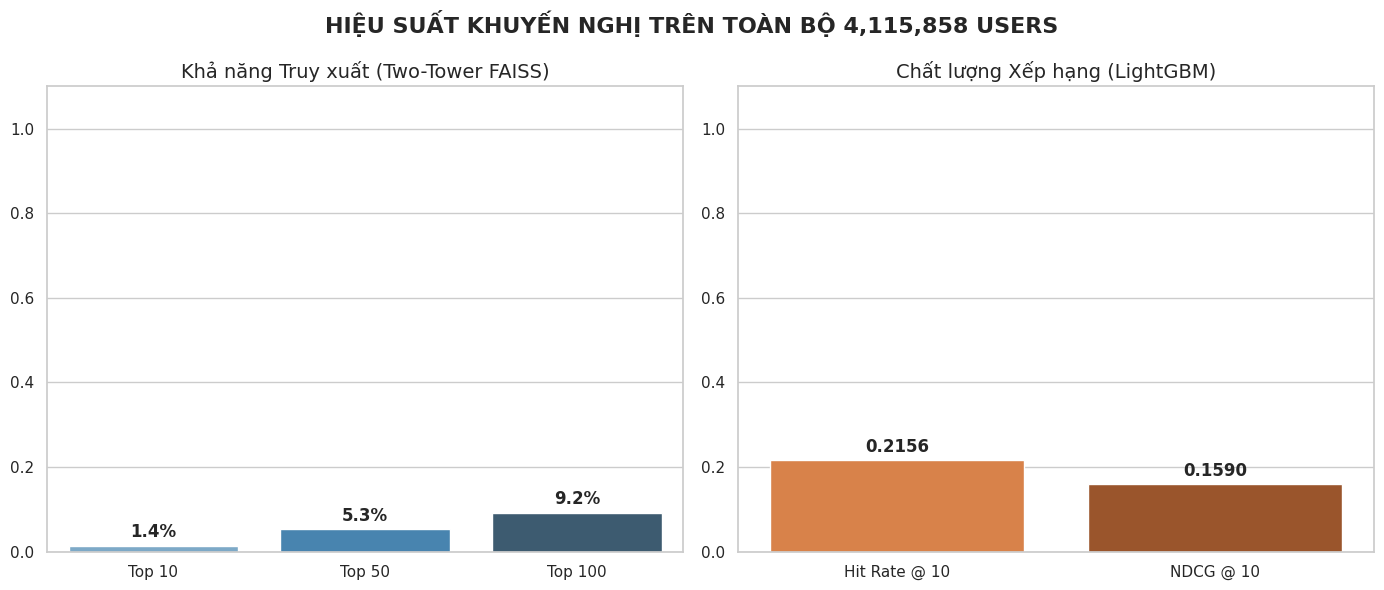

HOÀN TẤT ĐÁNH GIÁ SOTA! TỔNG THỜI GIAN CHẠY: 155.66 phút


In [3]:
# ====================================================================================
# CELL 4: ĐÁNH GIÁ HỆ THỐNG TRÊN TOÀN BỘ TẬP TEST (VECTORIZED & STREAMING OOM-FREE)
# ====================================================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
import duckdb
import faiss
import tensorflow as tf
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time

try:
    from tqdm.notebook import tqdm
except ImportError:
    !pip install tqdm
    from tqdm.notebook import tqdm

total_start_time = time.time()
BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
REPORT_DIR = f'{BASE_PATH}/reports'
MODEL_DIR = f'{BASE_PATH}/models'
os.makedirs(REPORT_DIR, exist_ok=True)

# Khởi tạo DB
con = duckdb.connect()
con.execute("PRAGMA memory_limit='8GB'")
con.execute("PRAGMA threads=4")

TOTAL_TEST_USERS = con.execute(f"SELECT COUNT(DISTINCT author_id) FROM read_parquet('{BASE_PATH}/test_interactions.parquet')").fetchone()[0]

print("="*80)
print(f"ĐÁNH GIÁ HỆ THỐNG SIÊU TỐC TRÊN TOÀN BỘ {TOTAL_TEST_USERS:,} USERS".center(80))
print("="*80)

print(f"\n[1/3] Đang trích xuất dữ liệu gốc của toàn bộ {TOTAL_TEST_USERS:,} Users...")
con.execute(f"""
    CREATE TEMPORARY TABLE eval_users AS
    WITH FullTest AS (
        SELECT author_id, appid as true_appid
        FROM read_parquet('{BASE_PATH}/test_interactions.parquet')
    )
    SELECT
        CAST(author_id AS VARCHAR) as author_id,
        CAST(true_appid AS VARCHAR) as true_appid,
        ROW_NUMBER() OVER() as batch_idx
    FROM FullTest
""")

test_df = con.execute(f"""
    WITH UserHistory AS (
        SELECT CAST(author_id AS VARCHAR) as author_id, string_agg(CAST(appid AS VARCHAR), ' ') as history_appids
        FROM read_parquet('{BASE_PATH}/train_interactions.parquet')
        WHERE reverse_chron_rank <= 30
        GROUP BY author_id
    )
    SELECT
        e.author_id, e.true_appid,
        COALESCE(h.history_appids, '') as history_appids,
        COALESCE(CAST(u.primary_language AS VARCHAR), 'unknown') as primary_language,
        CAST(COALESCE(u.avg_playtime_all_games, 0.0) AS REAL) as u_avg_playtime,
        CAST(COALESCE(u.deck_usage_ratio, 0.0) AS REAL) as deck_usage,
        CAST(COALESCE(u.total_reviews_written, 0.0) AS REAL) as total_reviews
    FROM eval_users e
    LEFT JOIN UserHistory h ON e.author_id = h.author_id
    LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON CAST(e.author_id AS BIGINT) = u.author_id
    ORDER BY e.batch_idx
""").fetch_arrow_table().to_pandas()

print("\n[2/3] Bắt đầu Pipeline Đánh giá Cuốn chiếu (Streaming Evaluation)...")
# Load Models
user_model = tf.saved_model.load(f'{MODEL_DIR}/two_tower_user_model')

# Kích hoạt FAISS GPU
cpu_index = faiss.read_index(f'{MODEL_DIR}/faiss_game_index.bin')
res = faiss.StandardGpuResources()
faiss_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)
faiss_appids = np.load(f'{MODEL_DIR}/faiss_appids.npy', allow_pickle=True).astype(str)

ranker = lgb.Booster(model_file=f'{MODEL_DIR}/lightgbm_ranker.txt')

features = [
    'avg_playtime_all_games', 'steam_purchase_ratio', 'total_reviews_written', 'max_games_owned',
    'positive_review_ratio', 'avg_weighted_score', 'avg_review_length', 'deep_review_ratio',
    'total_reviews', 'playtime_diff_ratio', 'quality_score'
]

recall_10_tt, recall_50_tt, recall_100_tt = 0, 0, 0
hits_10_lgb, ndcg_sum_lgb = 0, 0.0

# Xử lý cuốn chiếu từng Lô 50.000 Users (Cân bằng hoàn hảo giữa GPU VRAM và CPU RAM)
batch_size_eval = 50000

for i in tqdm(range(0, TOTAL_TEST_USERS, batch_size_eval), desc="Tiến trình Đánh giá"):
    # Lấy lô dữ liệu
    batch_df = test_df.iloc[i : i + batch_size_eval]

    # 1. TRÍCH XUẤT VECTOR BẰNG TF.DATA (Không bị lỗi Protobuf 2GB)
    dataset = tf.data.Dataset.from_tensor_slices({
        "appid": np.full(len(batch_df), "", dtype=str),
        "history_appids": batch_df['history_appids'].values.astype(str),
        "categories": np.full(len(batch_df), "", dtype=str),
        "primary_language": batch_df['primary_language'].values.astype(str),
        "u_avg_playtime": batch_df['u_avg_playtime'].values.astype(np.float32),
        "deck_usage": batch_df['deck_usage'].values.astype(np.float32),
        "total_reviews": batch_df['total_reviews'].values.astype(np.float32),
        "pos_review_ratio": np.zeros(len(batch_df), dtype=np.float32),
        "g_avg_playtime": np.zeros(len(batch_df), dtype=np.float32)
    }).batch(4096)

    emb_list = [user_model(b).numpy() for b in dataset]
    user_embeddings = np.concatenate(emb_list, axis=0)

    # 2. TÌM KIẾM FAISS GPU SIÊU TỐC
    _, indices = faiss_index.search(user_embeddings, 100)
    retrieved_games = faiss_appids[indices] # Mảng 2 chiều: [len(batch_df), 100]

    # 3. TÍNH RECALL TWO-TOWER (BẰNG MA TRẬN VECTOR HÓA CỰC NHANH)
    true_games = batch_df['true_appid'].values
    hits = (retrieved_games == true_games[:, None]) # So khớp tức thì

    recall_10_tt += hits[:, :10].any(axis=1).sum()
    recall_50_tt += hits[:, :50].any(axis=1).sum()
    recall_100_tt += hits[:, :100].any(axis=1).sum()

    # 4. CHUẨN BỊ CANDIDATES CHO LIGHTGBM (Không dùng vòng lặp for)
    author_ids = batch_df['author_id'].values
    author_col = np.repeat(author_ids, 100)
    appid_col = retrieved_games.flatten()

    # Đăng ký thẳng vào DuckDB không tốn RAM
    chunk_candidates_df = pd.DataFrame({'author_id': author_col, 'appid': appid_col})
    con.execute("DROP VIEW IF EXISTS current_candidates")
    con.register("current_candidates", chunk_candidates_df)

    # 5. LẤY FEATURES VÀ ĐÁNH GIÁ LIGHTGBM
    query = f"""
        WITH BatchUsers AS (
            SELECT author_id, true_appid
            FROM eval_users
            WHERE batch_idx > {i} AND batch_idx <= {i + len(batch_df)}
        ),
        FaissCandidates AS (
            SELECT b.author_id, f.appid, 0 as is_true
            FROM BatchUsers b
            JOIN current_candidates f ON b.author_id = f.author_id
            WHERE f.appid != b.true_appid
        )
        SELECT c.author_id, c.appid, c.is_true,
              CAST(COALESCE(u.avg_playtime_all_games, 0) AS REAL) as avg_playtime_all_games,
              CAST(COALESCE(u.steam_purchase_ratio, 0) AS REAL) as steam_purchase_ratio,
              CAST(COALESCE(u.total_reviews_written, 0) AS REAL) as total_reviews_written,
              CAST(COALESCE(u.max_games_owned, 0) AS REAL) as max_games_owned,
              CAST(COALESCE(g.positive_review_ratio, 0) AS REAL) as positive_review_ratio,
              CAST(COALESCE(g.avg_weighted_score, 0) AS REAL) as avg_weighted_score,
              CAST(COALESCE(g.avg_review_length, 0) AS REAL) as avg_review_length,
              CAST(COALESCE(g.deep_review_ratio, 0) AS REAL) as deep_review_ratio,
              CAST(COALESCE(g.total_reviews, 0) AS REAL) as total_reviews,
              CAST(ABS(COALESCE(u.avg_playtime_all_games, 0) - COALESCE(g.global_avg_playtime, 0)) /
                    (COALESCE(g.global_avg_playtime, 1) + 1) AS REAL) as playtime_diff_ratio,
              CAST(COALESCE(g.positive_review_ratio, 0) * COALESCE(g.avg_weighted_score, 0) AS REAL) as quality_score
        FROM (
            SELECT author_id, true_appid as appid, 1 as is_true FROM BatchUsers
            UNION ALL
            SELECT author_id, appid, is_true FROM FaissCandidates
        ) c
        LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON CAST(c.author_id AS BIGINT) = u.author_id
        LEFT JOIN read_parquet('{BASE_PATH}/game_features_enhanced.parquet') g ON CAST(c.appid AS BIGINT) = g.appid
    """

    try:
        lgb_df = con.execute(query).fetch_arrow_table().to_pandas()
        if not lgb_df.empty:
            lgb_df['score'] = ranker.predict(lgb_df[features])

            # Sắp xếp và lấy rank bằng Vectorized
            lgb_df = lgb_df.sort_values(by=['author_id', 'score'], ascending=[True, False])
            lgb_df['rank'] = lgb_df.groupby('author_id').cumcount() + 1

            true_hits = lgb_df[(lgb_df['is_true'] == 1) & (lgb_df['rank'] <= 10)]

            hits_10_lgb += len(true_hits)
            ndcg_sum_lgb += np.sum(1.0 / np.log2(true_hits['rank'] + 1))
    except Exception as e:
        print(f"Lỗi ở lô {i}: {e}")

    # Giải phóng rác bộ nhớ khổng lồ lập tức sau mỗi lô!
    del lgb_df, chunk_candidates_df, user_embeddings, retrieved_games, hits, dataset, emb_list
    gc.collect()

results_summary = {
    'Two-Tower': {
        'Recall@10': recall_10_tt / TOTAL_TEST_USERS,
        'Recall@50': recall_50_tt / TOTAL_TEST_USERS,
        'Recall@100': recall_100_tt / TOTAL_TEST_USERS
    },
    'LightGBM': {
        'Hit Rate@10': hits_10_lgb / TOTAL_TEST_USERS,
        'NDCG@10': ndcg_sum_lgb / TOTAL_TEST_USERS
    }
}

# --- 3. VẼ BIỂU ĐỒ VÀ XUẤT BÁO CÁO ---
print("\n[3/3] Đang xuất báo cáo đồ họa...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'HIỆU SUẤT KHUYẾN NGHỊ TRÊN TOÀN BỘ {TOTAL_TEST_USERS:,} USERS', fontsize=16, fontweight='bold')

x_tt = ['Top 10', 'Top 50', 'Top 100']
y_tt = [results_summary['Two-Tower']['Recall@10'], results_summary['Two-Tower']['Recall@50'], results_summary['Two-Tower']['Recall@100']]
sns.barplot(x=x_tt, y=y_tt, hue=x_tt, ax=axes[0], palette="Blues_d", legend=False)
axes[0].set_title('Khả năng Truy xuất (Two-Tower FAISS)', fontsize=14); axes[0].set_ylim(0, 1.1)
for i, v in enumerate(y_tt): axes[0].text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

x_lgb = ['Hit Rate @ 10', 'NDCG @ 10']
y_lgb = [results_summary['LightGBM']['Hit Rate@10'], results_summary['LightGBM']['NDCG@10']]
sns.barplot(x=x_lgb, y=y_lgb, hue=x_lgb, ax=axes[1], palette="Oranges_d", legend=False)
axes[1].set_title('Chất lượng Xếp hạng (LightGBM)', fontsize=14); axes[1].set_ylim(0, 1.1)
for i, v in enumerate(y_lgb): axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/recsys_performance_sota_{datetime.now().strftime('%Y%m%d_%H%M')}.png", dpi=300)
plt.show()

print("="*60)
print(f"HOÀN TẤT ĐÁNH GIÁ SOTA! TỔNG THỜI GIAN CHẠY: {(time.time() - total_start_time)/60:.2f} phút")
print("="*60)

test 50k


In [9]:
import duckdb
import os

BASE = '/content/drive/MyDrive/steam/steam_100M/processed_data'
SEED = 42
N    = 50000

con = duckdb.connect()
con.execute("PRAGMA memory_limit='4GB'")
con.execute("PRAGMA threads=4")

# Dùng hàm hash() kết hợp với SEED để xáo trộn dữ liệu ngẫu nhiên nhưng cố định 100%
con.execute(f"""
    COPY (
        SELECT author_id, appid AS true_appid
        FROM read_parquet('{BASE}/test_interactions.parquet')
        ORDER BY hash(CAST(author_id AS VARCHAR) || '_' || CAST(appid AS VARCHAR) || '_{SEED}')
        LIMIT {N}
    ) TO '{BASE}/eval_users_50k.parquet' (FORMAT PARQUET)
""")

cnt = con.execute(f"SELECT COUNT(*) FROM read_parquet('{BASE}/eval_users_50k.parquet')").fetchone()[0]
con.close()

print(f"Lưu thành công eval_users_50k.parquet: {cnt:,} users (seed={SEED})")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Lưu thành công eval_users_50k.parquet: 50,000 users (seed=42)


            BENCHMARK HỆ THỐNG SIÊU TỐC TRÊN TẬP CHUNG 50,000 USERS             

[1/3] Đang trích xuất dữ liệu gốc từ tập Benchmark...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


[2/3] Bắt đầu Pipeline Đánh giá Benchmark...


Tiến trình Benchmark:   0%|          | 0/1 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


[3/3] Đang xuất báo cáo Benchmark...


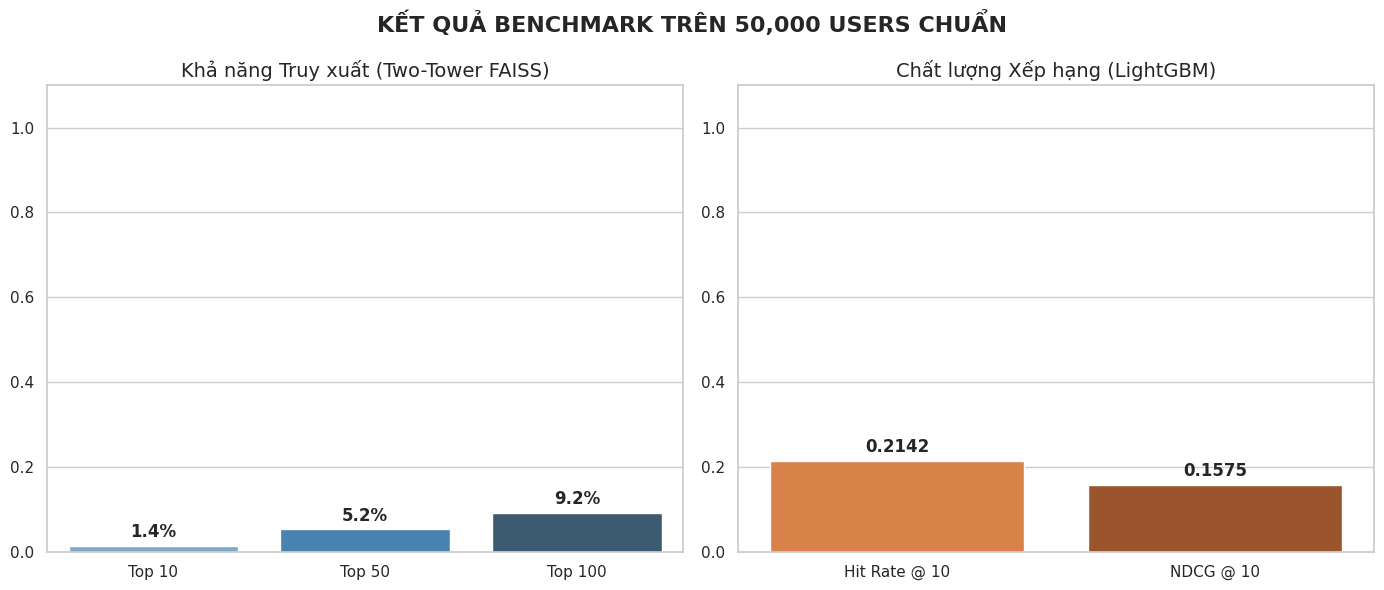

HOÀN TẤT BENCHMARK! Kết quả đã lưu tại: /content/drive/MyDrive/steam/steam_100M/processed_data/reports/benchmark_50k_20260611_1225.png
Tổng thời gian chạy: 124.91 giây


In [10]:
# ====================================================================================
# CELL 4: BENCHMARK HỆ THỐNG TRÊN TẬP TEST CHUNG (50K USERS - ULTRA FAST)
# ====================================================================================

# Tự động dọn dẹp và cài đặt phiên bản FAISS CPU ổn định nhất (Nếu bạn dùng Colab GPU thì nhớ đổi thành faiss-gpu-cu12 nhé)
!pip uninstall -y faiss faiss-cpu faiss-gpu faiss-gpu-cu11 faiss-gpu-cu12 > /dev/null 2>&1
!pip install -q faiss-gpu-cu12 lightgbm duckdb

import pandas as pd
import numpy as np
import lightgbm as lgb
import duckdb
import faiss
import tensorflow as tf
import os
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
from tqdm.notebook import tqdm

total_start_time = time.time()
BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
REPORT_DIR = f'{BASE_PATH}/reports'
MODEL_DIR = f'{BASE_PATH}/models'
BENCHMARK_PATH = f'{BASE_PATH}/eval_users_50k.parquet' # Trỏ vào tập Benchmark chung
os.makedirs(REPORT_DIR, exist_ok=True)

# Khởi tạo DB
con = duckdb.connect()
con.execute("PRAGMA memory_limit='8GB'")
con.execute("PRAGMA threads=4")

# Lấy tổng số Users từ tập Benchmark 50k
TOTAL_TEST_USERS = con.execute(f"SELECT COUNT(*) FROM read_parquet('{BENCHMARK_PATH}')").fetchone()[0]

print("="*80)
print(f"BENCHMARK HỆ THỐNG SIÊU TỐC TRÊN TẬP CHUNG {TOTAL_TEST_USERS:,} USERS".center(80))
print("="*80)

print(f"\n[1/3] Đang trích xuất dữ liệu gốc từ tập Benchmark...")
con.execute(f"""
    CREATE TEMPORARY TABLE eval_users AS
    WITH FullTest AS (
        SELECT author_id, true_appid
        FROM read_parquet('{BENCHMARK_PATH}')
    )
    SELECT
        CAST(author_id AS VARCHAR) as author_id,
        CAST(true_appid AS VARCHAR) as true_appid,
        ROW_NUMBER() OVER() as batch_idx
    FROM FullTest
""")

test_df = con.execute(f"""
    WITH UserHistory AS (
        SELECT CAST(author_id AS VARCHAR) as author_id, string_agg(CAST(appid AS VARCHAR), ' ') as history_appids
        FROM read_parquet('{BASE_PATH}/train_interactions.parquet')
        WHERE reverse_chron_rank <= 30
        GROUP BY author_id
    )
    SELECT
        e.author_id, e.true_appid,
        COALESCE(h.history_appids, '') as history_appids,
        COALESCE(CAST(u.primary_language AS VARCHAR), 'unknown') as primary_language,
        CAST(COALESCE(u.avg_playtime_all_games, 0.0) AS REAL) as u_avg_playtime,
        CAST(COALESCE(u.deck_usage_ratio, 0.0) AS REAL) as deck_usage,
        CAST(COALESCE(u.total_reviews_written, 0.0) AS REAL) as total_reviews
    FROM eval_users e
    LEFT JOIN UserHistory h ON e.author_id = h.author_id
    LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON CAST(e.author_id AS BIGINT) = u.author_id
    ORDER BY e.batch_idx
""").fetch_arrow_table().to_pandas()

print("\n[2/3] Bắt đầu Pipeline Đánh giá Benchmark...")
# Load Models
user_model = tf.saved_model.load(f'{MODEL_DIR}/two_tower_user_model')

# Kích hoạt FAISS GPU
cpu_index = faiss.read_index(f'{MODEL_DIR}/faiss_game_index.bin')
res = faiss.StandardGpuResources()
faiss_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)
faiss_appids = np.load(f'{MODEL_DIR}/faiss_appids.npy', allow_pickle=True).astype(str)

ranker = lgb.Booster(model_file=f'{MODEL_DIR}/lightgbm_ranker.txt')

features = [
    'avg_playtime_all_games', 'steam_purchase_ratio', 'total_reviews_written', 'max_games_owned',
    'positive_review_ratio', 'avg_weighted_score', 'avg_review_length', 'deep_review_ratio',
    'total_reviews', 'playtime_diff_ratio', 'quality_score'
]

recall_10_tt, recall_50_tt, recall_100_tt = 0, 0, 0
hits_10_lgb, ndcg_sum_lgb = 0, 0.0

# Batch size đặt bằng 50.000 để chạy đúng 1 vòng lặp là xong toàn bộ
batch_size_eval = 50000

for i in tqdm(range(0, TOTAL_TEST_USERS, batch_size_eval), desc="Tiến trình Benchmark"):
    # Lấy lô dữ liệu
    batch_df = test_df.iloc[i : i + batch_size_eval]

    # 1. TRÍCH XUẤT VECTOR BẰNG TF.DATA
    dataset = tf.data.Dataset.from_tensor_slices({
        "appid": np.full(len(batch_df), "", dtype=str),
        "history_appids": batch_df['history_appids'].values.astype(str),
        "categories": np.full(len(batch_df), "", dtype=str),
        "primary_language": batch_df['primary_language'].values.astype(str),
        "u_avg_playtime": batch_df['u_avg_playtime'].values.astype(np.float32),
        "deck_usage": batch_df['deck_usage'].values.astype(np.float32),
        "total_reviews": batch_df['total_reviews'].values.astype(np.float32),
        "pos_review_ratio": np.zeros(len(batch_df), dtype=np.float32),
        "g_avg_playtime": np.zeros(len(batch_df), dtype=np.float32)
    }).batch(4096)

    emb_list = [user_model(b).numpy() for b in dataset]
    user_embeddings = np.concatenate(emb_list, axis=0)

    # 2. TÌM KIẾM FAISS
    _, indices = faiss_index.search(user_embeddings, 100)
    retrieved_games = faiss_appids[indices]

    # 3. TÍNH RECALL BẰNG MA TRẬN VECTOR HÓA
    true_games = batch_df['true_appid'].values
    hits = (retrieved_games == true_games[:, None])

    recall_10_tt += hits[:, :10].any(axis=1).sum()
    recall_50_tt += hits[:, :50].any(axis=1).sum()
    recall_100_tt += hits[:, :100].any(axis=1).sum()

    # 4. CHUẨN BỊ CANDIDATES
    author_ids = batch_df['author_id'].values
    author_col = np.repeat(author_ids, 100)
    appid_col = retrieved_games.flatten()

    chunk_candidates_df = pd.DataFrame({'author_id': author_col, 'appid': appid_col})

    # ĐÃ SỬA LỖI DUCKDB: Dùng DROP VIEW thay vì DROP TABLE
    con.execute("DROP VIEW IF EXISTS current_candidates")
    con.register("current_candidates", chunk_candidates_df)

    # 5. LẤY FEATURES VÀ ĐÁNH GIÁ LIGHTGBM
    query = f"""
        WITH BatchUsers AS (
            SELECT author_id, true_appid
            FROM eval_users
            WHERE batch_idx > {i} AND batch_idx <= {i + len(batch_df)}
        ),
        FaissCandidates AS (
            SELECT b.author_id, f.appid, 0 as is_true
            FROM BatchUsers b
            JOIN current_candidates f ON b.author_id = f.author_id
            WHERE f.appid != b.true_appid
        )
        SELECT c.author_id, c.appid, c.is_true,
              CAST(COALESCE(u.avg_playtime_all_games, 0) AS REAL) as avg_playtime_all_games,
              CAST(COALESCE(u.steam_purchase_ratio, 0) AS REAL) as steam_purchase_ratio,
              CAST(COALESCE(u.total_reviews_written, 0) AS REAL) as total_reviews_written,
              CAST(COALESCE(u.max_games_owned, 0) AS REAL) as max_games_owned,
              CAST(COALESCE(g.positive_review_ratio, 0) AS REAL) as positive_review_ratio,
              CAST(COALESCE(g.avg_weighted_score, 0) AS REAL) as avg_weighted_score,
              CAST(COALESCE(g.avg_review_length, 0) AS REAL) as avg_review_length,
              CAST(COALESCE(g.deep_review_ratio, 0) AS REAL) as deep_review_ratio,
              CAST(COALESCE(g.total_reviews, 0) AS REAL) as total_reviews,
              CAST(ABS(COALESCE(u.avg_playtime_all_games, 0) - COALESCE(g.global_avg_playtime, 0)) /
                    (COALESCE(g.global_avg_playtime, 1) + 1) AS REAL) as playtime_diff_ratio,
              CAST(COALESCE(g.positive_review_ratio, 0) * COALESCE(g.avg_weighted_score, 0) AS REAL) as quality_score
        FROM (
            SELECT author_id, true_appid as appid, 1 as is_true FROM BatchUsers
            UNION ALL
            SELECT author_id, appid, is_true FROM FaissCandidates
        ) c
        LEFT JOIN read_parquet('{BASE_PATH}/user_features_full.parquet') u ON CAST(c.author_id AS BIGINT) = u.author_id
        LEFT JOIN read_parquet('{BASE_PATH}/game_features_enhanced.parquet') g ON CAST(c.appid AS BIGINT) = g.appid
    """

    try:
        lgb_df = con.execute(query).fetch_arrow_table().to_pandas()
        if not lgb_df.empty:
            lgb_df['score'] = ranker.predict(lgb_df[features])

            lgb_df = lgb_df.sort_values(by=['author_id', 'score'], ascending=[True, False])
            lgb_df['rank'] = lgb_df.groupby('author_id').cumcount() + 1

            true_hits = lgb_df[(lgb_df['is_true'] == 1) & (lgb_df['rank'] <= 10)]

            hits_10_lgb += len(true_hits)
            ndcg_sum_lgb += np.sum(1.0 / np.log2(true_hits['rank'] + 1))
    except Exception as e:
        print(f"Lỗi ở lô {i}: {e}")

    del lgb_df, chunk_candidates_df, user_embeddings, retrieved_games, hits, dataset, emb_list
    gc.collect()

results_summary = {
    'Two-Tower': {
        'Recall@10': recall_10_tt / TOTAL_TEST_USERS,
        'Recall@50': recall_50_tt / TOTAL_TEST_USERS,
        'Recall@100': recall_100_tt / TOTAL_TEST_USERS
    },
    'LightGBM': {
        'Hit Rate@10': hits_10_lgb / TOTAL_TEST_USERS,
        'NDCG@10': ndcg_sum_lgb / TOTAL_TEST_USERS
    }
}

# --- 3. VẼ BIỂU ĐỒ VÀ XUẤT BÁO CÁO ---
print("\n[3/3] Đang xuất báo cáo Benchmark...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'KẾT QUẢ BENCHMARK TRÊN {TOTAL_TEST_USERS:,} USERS CHUẨN', fontsize=16, fontweight='bold')

x_tt = ['Top 10', 'Top 50', 'Top 100']
y_tt = [results_summary['Two-Tower']['Recall@10'], results_summary['Two-Tower']['Recall@50'], results_summary['Two-Tower']['Recall@100']]
sns.barplot(x=x_tt, y=y_tt, hue=x_tt, ax=axes[0], palette="Blues_d", legend=False)
axes[0].set_title('Khả năng Truy xuất (Two-Tower FAISS)', fontsize=14); axes[0].set_ylim(0, 1.1)
for i, v in enumerate(y_tt): axes[0].text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

x_lgb = ['Hit Rate @ 10', 'NDCG @ 10']
y_lgb = [results_summary['LightGBM']['Hit Rate@10'], results_summary['LightGBM']['NDCG@10']]
sns.barplot(x=x_lgb, y=y_lgb, hue=x_lgb, ax=axes[1], palette="Oranges_d", legend=False)
axes[1].set_title('Chất lượng Xếp hạng (LightGBM)', fontsize=14); axes[1].set_ylim(0, 1.1)
for i, v in enumerate(y_lgb): axes[1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
benchmark_filename = f"{REPORT_DIR}/benchmark_50k_{datetime.now().strftime('%Y%m%d_%H%M')}.png"
plt.savefig(benchmark_filename, dpi=300)
plt.show()

print("="*60)
print(f"HOÀN TẤT BENCHMARK! Kết quả đã lưu tại: {benchmark_filename}")
print(f"Tổng thời gian chạy: {(time.time() - total_start_time):.2f} giây")
print("="*60)

Trien khai

In [1]:
# --- CELL 1: SUPER MASTER SETUP (CHẠY ĐẦU TIÊN MỖI KHI MỞ LẠI PHIÊN) ---

# 1. Cài đặt toàn bộ thư viện (nếu môi trường Colab vừa bị reset)
!pip install -q duckdb tensorflow-recommenders faiss-gpu-cu12 lightgbm sentence-transformers beautifulsoup4 pandas requests

# 2. Import tất cả các thư viện dùng trong mọi giai đoạn
import os
import gc
import time
import json
import requests
import re
import shutil
import duckdb
import numpy as np
import pandas as pd
import scipy.special
from sklearn.feature_extraction.text import TfidfVectorizer

# Cấu hình tương thích cho TensorFlow Recommenders
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
import tensorflow_recommenders as tfrs

import faiss
import lightgbm as lgb
from sentence_transformers import SentenceTransformer

# 3. Kết nối Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 4. KHAI BÁO TOÀN BỘ ĐƯỜNG DẪN TỪ A TỚI Z
# -- Đường dẫn gốc --
DRIVE_BASE_PATH = '/content/drive/MyDrive/steam/steam_100M'
LOCAL_BASE_PATH = '/content/steam_local_temp'
BASE_PATH = f'{DRIVE_BASE_PATH}/processed_data'
MODEL_DIR = f'{BASE_PATH}/models'

# -- Đường dẫn mảng Data Engineering (Xử lý dữ liệu) --
DRIVE_REVIEWS_DIR = f'{DRIVE_BASE_PATH}/reviews/reviews'
LOCAL_REVIEWS_DIR = f'{LOCAL_BASE_PATH}/reviews'
DRIVE_OUTPUT_DIR = BASE_PATH

# -- Đường dẫn mảng Machine Learning (Train & Inference) --
TEXT_PATH = f'{BASE_PATH}/reviews_text_only.parquet'
API_PATH = f'{BASE_PATH}/game_features_api.parquet'
ENRICHED_API_PATH = f'{BASE_PATH}/game_features_api_enriched.parquet'

USER_FEAT_PATH = f'{BASE_PATH}/user_features_full.parquet'
GAME_FEAT_PATH = f'{BASE_PATH}/game_features_enhanced.parquet'
TRAIN_INTERACTIONS = f'{BASE_PATH}/train_interactions.parquet'

# Khai báo riêng cho phần Triển khai (Deployment)
GAME_API_PATH = ENRICHED_API_PATH
STEAM_API_KEY = "84FF2705598E2FD2B7B92901E691BA4A"

# =========================================================================
# 5. KHAI BÁO VÀ LOAD SẴN FAISS NLP INDEX (Tránh lỗi NameError mọi nơi)
# =========================================================================
FAISS_NLP_INDEX_PATH = f"{MODEL_DIR}/faiss_nlp_index.bin"
FAISS_NLP_APPIDS_PATH = f"{MODEL_DIR}/faiss_nlp_appids.npy"

if os.path.exists(FAISS_NLP_INDEX_PATH) and os.path.exists(FAISS_NLP_APPIDS_PATH):
    faiss_nlp_index = faiss.read_index(FAISS_NLP_INDEX_PATH)
    faiss_nlp_appids = np.load(FAISS_NLP_APPIDS_PATH, allow_pickle=True)

    # Đồng bộ 2 tên biến (vì Cell Eval và Cell Deploy bị lệch tên)
    faiss_text_index = faiss_nlp_index
    faiss_text_appids = faiss_nlp_appids

    print(f"-> Đã load NLP FAISS Index (chứa {len(faiss_nlp_appids)} games) sẵn sàng cho mọi Cell!")
else:
    # Nếu file chưa tồn tại (chưa chạy hàm Build Index) thì gán None để chạy bỏ qua an toàn
    faiss_nlp_index = None
    faiss_nlp_appids = None
    faiss_text_index = None
    faiss_text_appids = None
    print("-> Cảnh báo: Chưa tìm thấy NLP FAISS Index trong thư mục models/ (Sẽ bỏ qua nhánh NLP).")

print("\n" + "="*70)
print("[THÀNH CÔNG] Khởi tạo hoàn tất! Toàn bộ biến môi trường đã sẵn sàng.")
print("Bây giờ có thể nhảy cóc chạy BẤT KỲ cell code nào ở dưới.")
print("="*70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 19.9 MB/s eta 0:00:00
Mounted at /content/drive
-> Đã load NLP FAISS Index (chứa 26367 games) sẵn sàng cho mọi Cell!

[THÀNH CÔNG] Khởi tạo hoàn tất! Toàn bộ biến môi trường đã sẵn sàng.
Bây giờ có thể nhảy cóc chạy BẤT KỲ cell code nào ở dưới.


In [ ]:
# ====================================================================================
# CELL 1: KHỞI TẠO HỆ THỐNG VÀ NẠP MÔ HÌNH AI (ĐƯỜNG DẪN GOOGLE DRIVE THỰC TẾ)
# ====================================================================================

import tensorflow as tf

# --------------------------------------------------------
# 1. MAGIC CODE: ÉP TENSORFLOW CHIA SẺ VRAM GPU
# --------------------------------------------------------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Đã ép TensorFlow giới hạn VRAM thành công! Không lo sập Kernel.")
    except RuntimeError as e:
        print(f"Lỗi cấu hình GPU: {e}")

# --------------------------------------------------------
# 2. IMPORT CÁC THƯ VIỆN KHÁC VÀ NẠP MÔ HÌNH
# --------------------------------------------------------
import pandas as pd
import numpy as np
import duckdb
import faiss
import lightgbm as lgb
import os # Bổ sung thêm thư viện os để kiểm tra file
from sentence_transformers import SentenceTransformer

print("1. Dang khoi tao He thong Khuyen nghi Hybrid SOTA (Multi-branch)...")
print("2. Dang tai cac mo hinh AI vao bo nho RAM...")

# --------------------------------------------------------
# 3. ĐƯỜNG DẪN DỮ LIỆU TỪ GOOGLE DRIVE
# --------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/steam/steam_100M/processed_data/"

# File dữ liệu
GAME_API_PATH = BASE_DIR + "game_features_api_enriched.parquet"
GAME_FEAT_PATH = BASE_DIR + "game_features_enhanced.parquet"
USER_FEAT_PATH = BASE_DIR + "user_features_full.parquet"

# File mô hình
FAISS_TEXT_INDEX_PATH = BASE_DIR + "models/faiss_text_index.bin"
FAISS_TEXT_APPIDS_PATH = BASE_DIR + "models/faiss_text_appids.npy"

TFRS_MODEL_PATH = BASE_DIR + "models/two_tower_user_model"
FAISS_INDEX_PATH = BASE_DIR + "models/faiss_game_index.bin"
FAISS_APPIDS_PATH = BASE_DIR + "models/faiss_appids.npy"
LGBM_MODEL_PATH = BASE_DIR + "models/lightgbm_ranker.txt"

# --------------------------------------------------------
# 4. KẾT NỐI DUCKDB VÀ NẠP DATABASE VÀO RAM (SIÊU TỐC)
# --------------------------------------------------------
con = duckdb.connect(config={'allow_unsigned_extensions': 'true'})
con.execute("PRAGMA threads=4")

print("Đang bốc toàn bộ Dữ liệu từ Google Drive vào RAM (Chỉ mất vài giây)...")
try:
    # Lệnh này sẽ copy dữ liệu từ Drive vào thẳng bộ nhớ tạm của DuckDB
    con.execute(f"CREATE TABLE IF NOT EXISTS game_api AS SELECT * FROM read_parquet('{GAME_API_PATH}')")
    con.execute(f"CREATE TABLE IF NOT EXISTS game_feat AS SELECT * FROM read_parquet('{GAME_FEAT_PATH}')")
    con.execute(f"CREATE TABLE IF NOT EXISTS user_feat AS SELECT * FROM read_parquet('{USER_FEAT_PATH}')")
    print("-> Nạp Database vào RAM thành công! Truy vấn giờ đây sẽ tính bằng mili-giây.")
except Exception as e:
    print(f"Lỗi khi nạp Database vào RAM: {e}")

# --------------------------------------------------------
# 5. LOAD MÔ HÌNH TOÀN HỆ THỐNG
# --------------------------------------------------------
try:
    # 5.1 Load mô hình Nhánh B (Two-Tower & Xếp hạng)
    user_model = tf.saved_model.load(TFRS_MODEL_PATH)
    faiss_index = faiss.read_index(FAISS_INDEX_PATH)
    faiss_appids = np.load(FAISS_APPIDS_PATH, allow_pickle=True)
    ranker = lgb.Booster(model_file=LGBM_MODEL_PATH)

    # 5.2 Load mô hình NLP
    nlp_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    # 5.3 [ĐÃ THÊM] Load mô hình FAISS Text (Tìm kiếm Ngữ nghĩa)
    if os.path.exists(FAISS_TEXT_INDEX_PATH) and os.path.exists(FAISS_TEXT_APPIDS_PATH):
        faiss_text_index = faiss.read_index(FAISS_TEXT_INDEX_PATH)
        faiss_text_appids = np.load(FAISS_TEXT_APPIDS_PATH, allow_pickle=True)
        print("-> Đã nạp thành công FAISS Text Index từ Drive!")
    else:
        # Gán None để Cell 3 biết đường tự động tạo mới nếu chưa có
        faiss_text_index = None
        faiss_text_appids = None

    print("Load toan bo mo hinh AI thanh cong.")
except Exception as e:
    print(f"LỖI LOAD MÔ HÌNH: {e}")

print("-> Khởi tạo hoàn tất. Hệ thống sẵn sàng!")

1. Dang khoi tao He thong Khuyen nghi Hybrid SOTA (Multi-branch)...
2. Dang tai cac mo hinh AI vao bo nho RAM...
Đang bốc toàn bộ Dữ liệu từ Google Drive vào RAM (Chỉ mất vài giây)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-> Nạp Database vào RAM thành công! Truy vấn giờ đây sẽ tính bằng mili-giây.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


-> Đã nạp thành công FAISS Text Index từ Drive!
Load toan bo mo hinh AI thanh cong.
-> Khởi tạo hoàn tất. Hệ thống sẵn sàng!


In [ ]:
# ====================================================================================
# CELL 2: THU THẬP DỮ LIỆU LIVE & TIỀN XỬ LÝ TEXT SOTA (BẢN TỐI ƯU CÀO 500 GAME + FALLBACK)
# ====================================================================================

import requests
import pandas as pd
import time
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- KHAI BÁO ĐƯỜNG DẪN CHUẨN ---
BASE_PATH = '/content/drive/MyDrive/steam/steam_100M/processed_data'
GAME_API_PATH = f"{BASE_PATH}/game_features_api_enriched.parquet"
GAME_FEAT_PATH = f"{BASE_PATH}/game_features_enhanced.parquet"
USER_FEAT_PATH = f"{BASE_PATH}/user_features_full.parquet"

STEAM_API_KEY = "84FF2705598E2FD2B7B92901E691BA4A"

def clean_game_text(game_name, genres, categories):
    raw_text = f"{game_name} {genres} {categories}"
    clean_text = raw_text.replace(',', ' ').replace('Free To Play', 'F2P').replace('Free to Play', 'F2P')

    noise_words = [
        'Steam Achievements', 'Steam Trading Cards', 'In-App Purchases', 'Steam Cloud',
        'Family Sharing', 'Captions available', 'Profile Features Limited', 'Includes level editor',
        'Remote Play on Phone', 'Remote Play on Tablet', 'Remote Play on TV', 'Remote Play Together',
        'Custom Volume Controls', 'Playable without Timed Input', 'Camera Comfort',
        'Adjustable Difficulty', 'Stereo Sound', 'Surround Sound', 'Keyboard Only Option',
        'Mouse Only Option', 'HDR available', 'Tracked Controller Support'
    ]
    for word in noise_words:
        clean_text = clean_text.replace(word, '')
    return " ".join(clean_text.split())

def get_entire_wishlist(steam_id):
    url = "https://api.steampowered.com/IWishlistService/GetWishlist/v1/"
    try:
        resp = requests.get(url, params={'steamid': steam_id, 'key': STEAM_API_KEY}, timeout=10).json()
        return [str(item['appid']) for item in resp.get('response', {}).get('items', [])]
    except: return []

def get_entire_library(steam_id):
    url = f"http://api.steampowered.com/IPlayerService/GetOwnedGames/v0001/?key={STEAM_API_KEY}&steamid={steam_id}&include_appinfo=1&include_played_free_games=1&format=json"
    library_dict = {}
    try:
        resp = requests.get(url, timeout=5).json()
        if 'response' in resp and 'games' in resp['response']:
            for g in resp['response']['games']:
                library_dict[str(g['appid'])] = g.get('playtime_forever', 0) + (g.get('playtime_2weeks', 0) * 5)
    except: pass
    return library_dict

def fetch_web_game_data(appid, game_name="Unknown", session=None):
    req = session if session else requests
    genres_text, tags_text = "" , ""

    try:
        resp = req.get(f"https://steamspy.com/api.php?request=appdetails&appid={appid}", timeout=5).json()
        if resp:
            if 'genre' in resp and resp['genre']: genres_text = resp['genre']
            if 'name' in resp and resp['name']: game_name = resp['name']
            if 'tags' in resp and isinstance(resp['tags'], dict):
                # Lấy top 20 User Tags
                tags_text = " ".join(list(resp['tags'].keys())[:20])
    except: pass

    if not genres_text or not tags_text:
        try:
            resp = req.get(f"https://store.steampowered.com/api/appdetails?appids={appid}&cc=us&l=english", timeout=5).json()
            if resp and resp.get(str(appid), {}).get('success'):
                data = resp[str(appid)]['data']
                game_name = data.get('name', game_name)
                if not genres_text and 'genres' in data:
                    genres_text = " ".join([c['description'] for c in data['genres']])
                if not tags_text and 'categories' in data:
                    tags_text = " ".join([c['description'] for c in data['categories']])
        except: pass

    text_data = clean_game_text(game_name, genres_text, tags_text)
    return {'appid': str(appid), 'name': game_name, 'genres': genres_text, 'text_data': text_data}

def get_trending_candidates_with_features(blacklist_appids, pool_size=500):
    print(f"-> [Khám phá] Đang vét cạn tối đa {pool_size} game Popular New trên Steam...")
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124.0.0.0 Safari/537.36'}
    candidates = []
    offset = 0

    # BƯỚC 1: LẬT TRANG LIÊN TỤC TRÊN STEAM SEARCH CHỐNG KHÓA IP
    with requests.Session() as session:
        session.headers.update(headers)
        while offset < pool_size:
            url = f"https://store.steampowered.com/search/results/?filter=popularnew&sort_by=Released_DESC&os=win&start={offset}&count=50&infinite=1"
            try:
                res = session.get(url, timeout=10)
                if res.status_code != 200:
                    break # Bị block thì thoát vòng lặp, xử lý số lượng đã lấy

                html = res.json().get('results_html', '')
                if not html: break

                soup = BeautifulSoup(html, 'html.parser')
                rows = soup.find_all('a', class_='search_result_row')
                if not rows: break

                for row in rows:
                    appid = row.get('data-ds-appid')
                    title_elem = row.find('span', class_='title')
                    if appid and title_elem:
                        if ',' in appid: appid = appid.split(',')[0]
                        if str(appid) not in blacklist_appids:
                            candidates.append({'appid': str(appid), 'name': title_elem.text.strip()})

                offset += 50
                time.sleep(0.5) # Nghỉ 0.5s chống Block IP
            except:
                break

    df_raw = pd.DataFrame(candidates).drop_duplicates(subset=['appid']).head(pool_size)

    # BƯỚC 2 (PHƯƠNG ÁN B): NẾU MẠNG CHẾT HOẶC BỊ CHẶN HOÀN TOÀN -> LẤY TỪ LOCAL DB
    if df_raw.empty:
        print("   [!] Cảnh báo: IP bị Steam chặn hoặc không có mạng.")
        print(f"   -> Kích hoạt Phương án cứu hộ: Lấy {pool_size} Game Phổ Biến từ Local DB...")
        bl_str = ", ".join([f"'{x}'" for x in blacklist_appids]) if blacklist_appids else "''"
        fallback_query = f"""
            SELECT CAST(a.appid AS VARCHAR) as appid, a.name, a.genres, a.categories
            FROM read_parquet('{GAME_API_PATH}') a
            JOIN read_parquet('{GAME_FEAT_PATH}') e ON CAST(a.appid AS BIGINT) = e.appid
            WHERE CAST(a.appid AS VARCHAR) NOT IN ({bl_str})
            ORDER BY e.total_reviews DESC NULLS LAST
            LIMIT {pool_size}
        """
        try:
            db_fallback = con.execute(fallback_query).df()
            live_metadata = []
            for _, row in db_fallback.iterrows():
                aid = str(row['appid'])
                txt = clean_game_text(row['name'] or "", row['genres'] or "", row['categories'] or "")
                if txt.strip():
                    live_metadata.append({'appid': aid, 'name': row['name'], 'text_data': txt})
            print(f"   + Đã cứu nguy thành công {len(live_metadata)} game từ DB.")
            return pd.DataFrame(live_metadata)
        except Exception as e:
            return pd.DataFrame()

    print(f"   + Vét thành công {len(df_raw)} game. Đang trích xuất đặc trưng (Text)...")
    live_metadata = []

    # BƯỚC 3: ƯU TIÊN TÌM TEXT TỪ DATABASE LOCAL CHO NHANH
    try:
        appids_str = ", ".join([f"'{x}'" for x in df_raw['appid']])
        query = f"SELECT CAST(appid AS VARCHAR) as appid, name, genres, categories FROM read_parquet('{GAME_API_PATH}') WHERE CAST(appid AS VARCHAR) IN ({appids_str})"
        db_df = con.execute(query).df()

        db_found = set()
        for _, row in db_df.iterrows():
            aid = str(row['appid'])
            db_found.add(aid)
            text_data = clean_game_text(row['name'] or "", row['genres'] or "", row['categories'] or "")
            if text_data.strip():
                live_metadata.append({'appid': aid, 'name': row['name'], 'genres': row['genres'], 'text_data': text_data})

        appids_to_fetch_web = [row for _, row in df_raw.iterrows() if str(row['appid']) not in db_found]
    except:
        appids_to_fetch_web = [row for _, row in df_raw.iterrows()]

    # BƯỚC 4: GAME NÀO QUÁ MỚI CHƯA CÓ TRONG DB THÌ MỚI CÀO WEB (TIẾT KIỆM THỜI GIAN)
    if appids_to_fetch_web:
        with requests.Session() as thread_session:
            with ThreadPoolExecutor(max_workers=10) as executor:
                futures = {executor.submit(fetch_web_game_data, row['appid'], row['name'], thread_session): row['appid'] for row in appids_to_fetch_web}
                for future in as_completed(futures):
                    try:
                        res = future.result()
                        if res['text_data'].strip():
                            live_metadata.append(res)
                    except: pass

    return pd.DataFrame(live_metadata)

In [ ]:
# ====================================================================================
# CELL 3: ĐỘNG CƠ GỢI Ý HYBRID SOTA (TỐI ƯU TOÁN HỌC & MỞ RỘNG BỂ ỨNG VIÊN)
# ====================================================================================

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import gc
import tensorflow as tf
import faiss
import os

# ------------------------------------------------------------------------------------
# 1. TẠO CACHE GLOBAL (GAME THỊNH HÀNH VÀ VECTOR TEXT CHO GAME CŨ)
# ------------------------------------------------------------------------------------
if 'GLOBAL_TRENDING_DF' not in globals() or GLOBAL_TRENDING_DF is None or len(GLOBAL_TRENDING_DF) == 0:
    print("\n[HỆ THỐNG] Đang khởi tạo Cache Game Thịnh hành...")
    # Tăng pool_size lên 1000 để dư dả game Mới cho các yêu cầu top_k lớn
    GLOBAL_TRENDING_DF = get_trending_candidates_with_features(blacklist_appids=set(), pool_size=1000)
    if not GLOBAL_TRENDING_DF.empty:
        GLOBAL_TREND_VECS = nlp_model.encode(GLOBAL_TRENDING_DF['text_data'].tolist(), normalize_embeddings=True, batch_size=32)
        print("-> Đã nạp Cache Game Mới thành công!\n")
    else:
        GLOBAL_TREND_VECS = None

if 'faiss_text_index' not in globals() or faiss_text_index is None:
    print("\n[HỆ THỐNG] Nhận diện chưa có FAISS Text Index. Đang khởi tạo Vector Text...")
    try:
        all_text_query = "SELECT CAST(a.appid AS VARCHAR) as appid, a.name, a.genres, a.categories FROM game_api a JOIN game_feat g ON CAST(a.appid AS BIGINT) = g.appid WHERE g.total_reviews > 50"
        all_text_df = con.execute(all_text_query).df()
        text_corpus, appids_list = [], []
        for _, row in all_text_df.iterrows():
            txt = clean_game_text(row['name'] or "", row['genres'] or "", row['categories'] or "")
            if txt.strip():
                text_corpus.append(txt)
                appids_list.append(str(row['appid']))

        print(f"-> Đang nhúng {len(text_corpus)} Game Cũ thành Vector (Mất khoảng 20-30s)...")
        corpus_vecs = nlp_model.encode(text_corpus, normalize_embeddings=True, batch_size=64)
        dim = corpus_vecs.shape[1]
        faiss_text_index = faiss.IndexFlatIP(dim)
        faiss_text_index.add(corpus_vecs)
        faiss_text_appids = np.array(appids_list)
        faiss.write_index(faiss_text_index, FAISS_TEXT_INDEX_PATH)
        np.save(FAISS_TEXT_APPIDS_PATH, faiss_text_appids)
        print("-> Khởi tạo FAISS Text Index thành công!\n")
        del all_text_df, text_corpus, corpus_vecs
        gc.collect()
    except Exception as e:
        print(f"Lỗi tạo FAISS Text: {e}")

# ------------------------------------------------------------------------------------
# 2. HÀM GỢI Ý LÕI (SOTA HYBRID ENGINE)
# ------------------------------------------------------------------------------------
def get_perfect_hybrid_recommendation(author_id, custom_query="", top_k=10, new_games_k=10, session_exclude=None, filter_nsfw=True):
    import time
    import duckdb
    import traceback
    start_time = time.time()

    if session_exclude is None: session_exclude = []
    author_id_str = str(author_id)
    local_con = duckdb.connect()

    # =========================================================
    # TỰ ĐỘNG TẠO BỘ NHỚ LỌC 18+ NẾU BỊ THIẾU
    # =========================================================
    global GLOBAL_NSFW_APPIDS
    if 'GLOBAL_NSFW_APPIDS' not in globals():
        print("-> [Hệ thống] Đang khởi tạo bộ nhớ Blacklist 18+...")
        try:
            nsfw_query = f"SELECT CAST(appid AS VARCHAR) as appid FROM read_parquet('{GAME_API_PATH}') WHERE genres ILIKE '%Nudity%' OR genres ILIKE '%Sexual Content%' OR genres ILIKE '%Hentai%' OR genres ILIKE '%NSFW%' OR genres ILIKE '%Adult Only%' OR categories ILIKE '%Nudity%' OR categories ILIKE '%Sexual Content%' OR name ILIKE '%Hentai%' OR name ILIKE '%Sex%'"
            nsfw_df = local_con.execute(nsfw_query).df()
            GLOBAL_NSFW_APPIDS = set(nsfw_df['appid'].tolist())
            print(f"-> Đã đưa {len(GLOBAL_NSFW_APPIDS)} game nhạy cảm vào Danh sách đen!")
        except:
            GLOBAL_NSFW_APPIDS = set()

    wishlist_appids = get_entire_wishlist(author_id_str)
    library_data = get_entire_library(author_id_str)

    # Gộp Blacklist và kích hoạt khiên 18+ nếu được yêu cầu
    blacklist_appids = set(wishlist_appids + list(library_data.keys()) + session_exclude)
    if filter_nsfw and GLOBAL_NSFW_APPIDS:
        blacklist_appids.update(GLOBAL_NSFW_APPIDS)
        print("-> [Chế độ An toàn] Đã kích hoạt khiên chặn game 18+.")
    else:
        print("-> [Chế độ Tự do] Lọc 18+ đã TẮT.")

    all_library_appids = list(library_data.keys())
    is_private = not wishlist_appids and not library_data

    # =========================================================
    # TẠO VECTOR SỞ THÍCH NGƯỜI DÙNG (USER TASTE VECTOR)
    # =========================================================
    user_vector = None
    if not is_private:
        all_ids = list(set(all_library_appids + wishlist_appids))
        all_ids_str = ", ".join([f"'{x}'" for x in all_ids]) if all_ids else "''"
        try:
            query_text = f"SELECT CAST(appid AS VARCHAR) as appid, name, genres, categories FROM read_parquet('{GAME_API_PATH}') WHERE CAST(appid AS VARCHAR) IN ({all_ids_str})"
            raw_text_df = local_con.execute(query_text).df()
            text_dict = {str(row['appid']): clean_game_text(row['name'] or "", row['genres'] or "", row['categories'] or "") for _, row in raw_text_df.iterrows()}

            text_weight_map = {}
            for aid in all_library_appids:
                if aid in text_dict:
                    pt = library_data.get(aid, 0) / 60
                    w = 1 if pt <= 0 else min(int(np.log1p(pt) * 2) + 2, 9)
                    if text_dict[aid].strip(): text_weight_map[text_dict[aid]] = text_weight_map.get(text_dict[aid], 0) + w

            for aid in wishlist_appids:
                if aid in text_dict and text_dict[aid].strip():
                    text_weight_map[text_dict[aid]] = text_weight_map.get(text_dict[aid], 0) + 20

            if text_weight_map:
                u_embs = nlp_model.encode(list(text_weight_map.keys()), normalize_embeddings=True, batch_size=32)
                u_weights = np.array(list(text_weight_map.values())).reshape(-1, 1)
                user_vector = np.sum(u_embs * u_weights, axis=0) / np.sum(u_weights)
                user_vector = user_vector.reshape(1, -1)
        except: pass

    has_query = bool(custom_query and custom_query.strip())
    query_vec = nlp_model.encode([custom_query.strip()], normalize_embeddings=True) if has_query else None
    if has_query: print(f"-> [AI Nhận diện] Tìm kiếm TỪ KHÓA TỐI THƯỢNG: '{custom_query}'")

    # =========================================================
    # NHÁNH A: GAME TRENDING MỚI PHÁT HÀNH
    # =========================================================
    trending_df = pd.DataFrame()
    if GLOBAL_TRENDING_DF is not None and not GLOBAL_TRENDING_DF.empty:
        valid_mask = ~GLOBAL_TRENDING_DF['appid'].isin(blacklist_appids)
        trending_df = GLOBAL_TRENDING_DF[valid_mask].copy()

        if not trending_df.empty:
            t_vecs = GLOBAL_TREND_VECS[valid_mask.values]
            trending_df['steam_link'] = "https://store.steampowered.com/app/" + trending_df['appid'].astype(str)

            if has_query:
                query_sims = np.clip(cosine_similarity(query_vec, t_vecs)[0], 0, 1) # Không cho phép âm
                if user_vector is not None:
                    user_sims = np.clip(cosine_similarity(user_vector, t_vecs)[0], 0, 1)
                    # [TỐI ƯU TOÁN HỌC]: PHÉP NHÂN - Query làm lõi, User_taste làm hệ số x1.3
                    final_sims = query_sims * (1.0 + user_sims * 0.30)
                else:
                    final_sims = query_sims
                mn, mx = final_sims.min(), final_sims.max()
                trending_df['match_probability'] = ((final_sims - mn) / (mx - mn + 1e-9) * 0.40) + 0.55 if mx > mn else 0.80
            elif user_vector is not None:
                user_sims = cosine_similarity(user_vector, t_vecs)[0]
                mn, mx = user_sims.min(), user_sims.max()
                trending_df['match_probability'] = ((user_sims - mn) / (mx - mn + 1e-9) * 0.40) + 0.55 if mx > mn else 0.80
            else:
                trending_df['match_probability'] = np.nan

            trending_df = trending_df.sort_values('match_probability', ascending=False).head(new_games_k)

    # =========================================================
    # NHÁNH B: GAME KINH ĐIỂN (FAISS + LIGHTGBM)
    # =========================================================
    catalog_df = pd.DataFrame()
    if is_private and not has_query:
        catalog_df = local_con.execute(f"SELECT CAST(appid AS VARCHAR) as appid, NULL as match_probability FROM read_parquet('{GAME_FEAT_PATH}') WHERE total_reviews > 10000 ORDER BY avg_weighted_score DESC LIMIT {top_k}").df()
    else:
        try:
            user_info = local_con.execute(f"SELECT COALESCE(CAST(primary_language AS VARCHAR), 'english') as primary_language, CAST(COALESCE(avg_playtime_all_games, 10.0) AS REAL) as u_avg_playtime, CAST(COALESCE(deck_usage_ratio, 0.0) AS REAL) as deck_usage, CAST(COALESCE(total_reviews_written, 1.0) AS REAL) as total_reviews FROM read_parquet('{USER_FEAT_PATH}') WHERE CAST(author_id AS VARCHAR) = '{author_id_str}'").df()
            u_lang, u_playtime, u_deck, u_rev = ('english', 10.0, 0.0, 1.0) if len(user_info) == 0 else (user_info['primary_language'].iloc[0], user_info['u_avg_playtime'].iloc[0], user_info['deck_usage'].iloc[0], user_info['total_reviews'].iloc[0])

            # 1. Tìm bằng Thói quen Giờ chơi (Quăng lưới cực sâu: 2000 ứng viên)
            user_emb = user_model({"author_id": tf.constant([author_id_str]), "primary_language": tf.constant([u_lang]), "u_avg_playtime": tf.constant([u_playtime], dtype=tf.float32), "deck_usage": tf.constant([u_deck], dtype=tf.float32), "total_reviews": tf.constant([u_rev], dtype=tf.float32), "appid": tf.constant([""]), "categories": tf.constant([""]), "pos_review_ratio": tf.constant([0.0], dtype=tf.float32), "g_avg_playtime": tf.constant([0.0], dtype=tf.float32)})
            distances_tt, indices_tt = faiss_index.search(user_emb.numpy(), 2000)
            faiss_dict = dict(zip([str(faiss_appids[x]) for x in indices_tt[0]], distances_tt[0]))

            # 2. Tìm bằng Sở thích (User Taste) trên toàn bộ kho
            user_taste_dict = {}
            if user_vector is not None and faiss_text_index is not None:
                dist_u, ind_u = faiss_text_index.search(user_vector, faiss_text_index.ntotal)
                user_taste_dict = dict(zip([str(faiss_text_appids[x]) for x in ind_u[0]], dist_u[0]))

            # Linh hoạt kích thước bể ứng viên để chống lỗi thiếu hụt game
            candidate_pool_size = max(300, top_k * 10)
            semantic_dict = {}
            filtered = []

            if has_query and faiss_text_index is not None:
                # Tìm bằng Từ khóa (Quăng lưới siêu sâu: 3000 ứng viên để bù đắp Blacklist)
                dist_q, ind_q = faiss_text_index.search(query_vec, 3000)
                semantic_dict = dict(zip([str(faiss_text_appids[x]) for x in ind_q[0]], dist_q[0]))
                filtered = [x for x in list(semantic_dict.keys()) if x not in blacklist_appids][:candidate_pool_size]
            else:
                half_pool = candidate_pool_size // 2
                filtered = list(set([x for x in list(faiss_dict.keys()) if x not in blacklist_appids][:half_pool] + [x for x in list(user_taste_dict.keys()) if x not in blacklist_appids][:half_pool]))

            if filtered:
                f_str = ", ".join([f"'{x}'" for x in filtered])
                df_f = local_con.execute(f"SELECT CAST(c.appid AS VARCHAR) as appid, CAST(COALESCE(g.positive_review_ratio, 0.0) AS REAL) as positive_review_ratio, CAST(COALESCE(g.avg_weighted_score, 0.0) AS REAL) as avg_weighted_score, CAST(COALESCE(g.total_reviews, 0) AS REAL) as total_reviews, CAST(COALESCE(u.avg_playtime_all_games, {u_playtime}) AS REAL) as avg_playtime_all_games, CAST(COALESCE(u.steam_purchase_ratio, 0.5) AS REAL) as steam_purchase_ratio, CAST(COALESCE(u.total_reviews_written, {u_rev}) AS REAL) as total_reviews_written, CAST(COALESCE(u.max_games_owned, 10) AS REAL) as max_games_owned, CAST(COALESCE(g.avg_review_length, 0.0) AS REAL) as avg_review_length, CAST(COALESCE(g.deep_review_ratio, 0.0) AS REAL) as deep_review_ratio, CAST(ABS(COALESCE(u.avg_playtime_all_games, {u_playtime}) - COALESCE(g.global_avg_playtime, 0)) AS REAL) as playtime_diff_abs FROM (SELECT unnest([{f_str}]) as appid) as c LEFT JOIN read_parquet('{GAME_FEAT_PATH}') g ON CAST(c.appid AS BIGINT) = g.appid LEFT JOIN read_parquet('{USER_FEAT_PATH}') u ON CAST(u.author_id AS VARCHAR) = '{author_id_str}'").df()

                df_f['raw_lgbm'] = ranker.predict(df_f[['avg_playtime_all_games', 'steam_purchase_ratio', 'total_reviews_written', 'max_games_owned', 'positive_review_ratio', 'avg_weighted_score', 'avg_review_length', 'deep_review_ratio', 'total_reviews', 'playtime_diff_abs']])
                df_f['faiss_score'] = df_f['appid'].map(faiss_dict).fillna(0)
                df_f['user_taste_score'] = df_f['appid'].map(user_taste_dict).fillna(0)

                if has_query:
                    df_f['semantic_score'] = df_f['appid'].map(semantic_dict).fillna(0)

                    # [TỐI ƯU TOÁN HỌC]: Tuyệt đối không Min-Max điểm Semantic để bảo toàn độ chính xác của Từ Khóa
                    df_f['n_semantic_score'] = np.clip(df_f['semantic_score'], 0, 1)
                    for c in ['user_taste_score', 'raw_lgbm']:
                        df_f[f'n_{c}'] = (df_f[c] - df_f[c].min()) / (df_f[c].max() - df_f[c].min() + 1e-9)

                    # PHÉP NHÂN CHIẾN LƯỢC: Điểm Từ Khóa * (1 + 30% Điểm Sở Thích + 10% Điểm Chất lượng)
                    df_f['hybrid'] = df_f['n_semantic_score'] * (1.0 + (df_f['n_user_taste_score'] * 0.30) + (df_f['n_raw_lgbm'] * 0.10))
                else:
                    # 1. BẢO TOÀN ĐIỂM SỞ THÍCH GỐC (Không Min-Max làm méo mó dữ liệu)
                    df_f['n_user_taste_score'] = np.clip(df_f['user_taste_score'], 0, 1)

                    # 2. CHỈ MIN-MAX ĐIỂM THÓI QUEN VÀ PHỔ BIẾN
                    for c in ['faiss_score', 'raw_lgbm']:
                        df_f[f'n_{c}'] = (df_f[c] - df_f[c].min()) / (df_f[c].max() - df_f[c].min() + 1e-9)

                    # 3. [TỐI ƯU TOÁN HỌC]: ÁP DỤNG PHÉP NHÂN CHO SỞ THÍCH (USER TASTE LÀ LÕI)
                    # Game nào lệch gu (Sở thích = 0) sẽ bị vô hiệu hóa hoàn toàn mọi điểm cộng khác!
                    df_f['hybrid'] = df_f['n_user_taste_score'] * (1.0 + (df_f['n_faiss_score'] * 0.30) + (df_f['n_raw_lgbm'] * 0.15))

                # Chuẩn hóa về thang 0.75 -> 0.95 để hiển thị đẹp mắt trên giao diện
                df_f['match_probability'] = (df_f['hybrid'] - df_f['hybrid'].min()) / (df_f['hybrid'].max() - df_f['hybrid'].min() + 1e-9) * 0.20 + 0.75
                catalog_df = df_f.sort_values('match_probability', ascending=False).head(top_k)
        except Exception as e:
            traceback.print_exc()

    if not catalog_df.empty:
        c_ids = ", ".join([f"'{x}'" for x in catalog_df['appid']])
        meta = local_con.execute(f"SELECT CAST(appid AS VARCHAR) as appid, name, genres, categories FROM read_parquet('{GAME_API_PATH}') WHERE CAST(appid AS VARCHAR) IN ({c_ids})").df()
        meta['tags_display'] = meta['genres'].fillna('') + " , " + meta['categories'].fillna('')
        catalog_df = pd.merge(catalog_df[['appid', 'match_probability']], meta, on='appid', how='inner')
        catalog_df['steam_link'] = "https://store.steampowered.com/app/" + catalog_df['appid'].astype(str)

    gc.collect()
    local_con.close()
    print(f"Phan tich thanh cong! Tra ve ket qua sau {time.time() - start_time:.2f} giay.")

    return {
        'catalog': catalog_df[['name', 'match_probability', 'tags_display', 'steam_link']] if not catalog_df.empty else pd.DataFrame(),
        'trending': trending_df[['name', 'match_probability', 'text_data', 'steam_link']] if not trending_df.empty else pd.DataFrame()
    }


[HỆ THỐNG] Đang khởi tạo Cache Game Thịnh hành...
-> [Khám phá] Đang vét cạn tối đa 1000 game Popular New trên Steam...
   + Vét thành công 392 game. Đang trích xuất đặc trưng (Text)...
-> Đã nạp Cache Game Mới thành công!



In [ ]:
# ====================================================================================
# CELL 4: THỰC THI DỰ ĐOÁN & HIỂN THỊ KẾT QUẢ
# ====================================================================================

import pandas as pd
import numpy as np

# Điền ID User bạn muốn kiểm tra vào đây
test_user_id = "76561199241018614"

print(f"\n[{test_user_id}] Bắt đầu quy trình dự đoán...\n")

# Chạy Động cơ Gợi ý SOTA
results = get_perfect_hybrid_recommendation(test_user_id, custom_query="", top_k=10, new_games_k=10, session_exclude=None, filter_nsfw=None)

def print_plain_text(df, section_title, is_trending=False):
    print("-" * 70)
    print(section_title.center(70))
    print("-" * 70)

    if df is None or df.empty:
        print("Không có dữ liệu cho mục này.\n")
        return

    df = df.reset_index(drop=True)

    for i, row in df.iterrows():
        name = row['name']
        prob_val = row['match_probability']
        link = row['steam_link']

        if pd.isna(prob_val):
            prob_str = "(Top Phổ Biến Toàn Cầu)" if not is_trending else "(Top Thịnh Hành Mới Nhất)"
        else:
            prob_str = f"(Độ Phù Hợp: {prob_val:.2%})"

        if not is_trending and 'tags_display' in row:
            tags = str(row['tags_display']).strip()
        elif 'text_data' in row:
            tags = str(row['text_data']).strip()
        elif 'genres' in row:
            tags = str(row['genres']).strip()
        else:
            tags = ""

        tags = tags.replace(" | ", ", ").strip(", ")
        if not tags or tags == "nan":
            tags = "Chưa cập nhật thông tin thể loại"

        print(f"{i+1}. {name} {prob_str}")
        print(f"   Thể loại: {tags}")
        print(f"   Link: {link}\n")

# --- IN KẾT QUẢ RA MÀN HÌNH ---
print("\n" + "="*70)
print("HỆ THỐNG KHUYẾN NGHỊ STEAM ĐA NHÁNH (MULTI-MODAL)".center(70))
print("="*70 + "\n")

print_plain_text(results.get('catalog', pd.DataFrame()), "DANH SÁCH SIÊU PHẨM KINH ĐIỂN (TWO-TOWER + LIGHTGBM)")
print_plain_text(results.get('trending', pd.DataFrame()), "DANH SÁCH GAME MỚI PHÁT HÀNH (NLP CACHE)", is_trending=True)


[76561199241018614] Bắt đầu quy trình dự đoán...

-> [Chế độ Tự do] Lọc 18+ đã TẮT.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Phan tich thanh cong! Tra ve ket qua sau 12.78 giay.

          HỆ THỐNG KHUYẾN NGHỊ STEAM ĐA NHÁNH (MULTI-MODAL)           

----------------------------------------------------------------------
         DANH SÁCH SIÊU PHẨM KINH ĐIỂN (TWO-TOWER + LIGHTGBM)         
----------------------------------------------------------------------
1. Rust (Độ Phù Hợp: 95.00%)
   Thể loại: Action, Adventure, Indie, Massively Multiplayer, RPG , Survival, Crafting, Multiplayer, Open World, Open World Survival Craft, Building, PvP, Sandbox, Adventure, First-Person, Action, Nudity, FPS, Shooter, Co-op, Online Co-Op, Indie, Post-apocalyptic, Early Access, Simulation
   Link: https://store.steampowered.com/app/252490

2. Noita (Độ Phù Hợp: 94.68%)
   Thể loại: Action, Adventure, Indie, RPG, Simulation , Physics, Roguelike, Pixel Graphics, Difficult, Dungeon Crawler, Indie, Sandbox, Open World, 2D, Perma Death, Action, Action Roguelike, Gun Customization, Roguelite, 2D Platformer, RPG, Dark Humor, Mythol

#Debug


In [ ]:
# ====================================================================================
# CELL 5: BẢNG ĐIỀU KHIỂN DEBUG ĐƯỢC TỐI ƯU HÓA MA TRẬN
# ====================================================================================

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity

test_user_id = "76561199241018614"
author_id_str = str(test_user_id)

print("="*100)
print("BẢNG ĐIỀU KHIỂN DEBUG: TRỌNG SỐ, VĂN BẢN VÀ MA TRẬN VECTOR".center(100))
print("="*100)

# ---------------------------------------------------------
# 1. TRÍCH XUẤT DỮ LIỆU THƯ VIỆN & WISHLIST
# ---------------------------------------------------------
wishlist_appids = get_entire_wishlist(author_id_str)
library_data = get_entire_library(author_id_str)
all_library_appids = list(library_data.keys())

all_ids = list(set(all_library_appids + wishlist_appids))
all_ids_str = ", ".join([f"'{x}'" for x in all_ids])

try:
    query_text = f"SELECT CAST(appid AS VARCHAR) as appid, name, genres, categories FROM read_parquet('{GAME_API_PATH}') WHERE CAST(appid AS VARCHAR) IN ({all_ids_str})"
    raw_text_df = con.execute(query_text).df()
    game_meta_dict = {
        str(row['appid']): {
            'name': row['name'] or "Unknown Game",
            'text': clean_game_text(row['name'] or "", row['genres'] or "", row['categories'] or "")
        } for _, row in raw_text_df.iterrows()
    }
except:
    game_meta_dict = {}

unique_texts = []
weights_list = []
debug_rows = []

# Xử lý Library
for aid in all_library_appids:
    if aid in game_meta_dict:
        pt_minutes = library_data.get(aid, 0)
        pt_hours = round(pt_minutes / 60, 2)
        w = 2 if pt_hours <= 0 else min(int(np.log1p(pt_hours) * 2) + 2, 9)

        name = game_meta_dict[aid]['name']
        text = game_meta_dict[aid]['text']

        unique_texts.append(text)
        weights_list.append(w)
        debug_rows.append({'Tên Game': name, 'Nguồn': 'Thư Viện', 'Giờ chơi (h)': pt_hours, 'Trọng số': w, 'Text Data': text})

# Xử lý Wishlist
for aid in wishlist_appids:
    if aid in game_meta_dict:
        name = game_meta_dict[aid]['name']
        text = game_meta_dict[aid]['text']

        unique_texts.append(text)
        weights_list.append(15)
        debug_rows.append({'Tên Game': name, 'Nguồn': 'Wishlist (DB)', 'Giờ chơi (h)': 0, 'Trọng số': 15, 'Text Data': text})
    else:
        live_data = fetch_web_game_data(aid, "Unknown Wishlist")
        text = live_data['text_data']
        if text.strip():
            unique_texts.append(text)
            weights_list.append(15)
            debug_rows.append({'Tên Game': live_data['name'], 'Nguồn': 'Wishlist (Live)', 'Giờ chơi (h)': 0, 'Trọng số': 15, 'Text Data': text})

print(f"\n[1] ĐANG XÂY DỰNG VECTOR SỞ THÍCH TỪ {len(debug_rows)} GAMES (Tối ưu Ma trận):")

user_vector = None
if debug_rows:
    df_debug = pd.DataFrame(debug_rows)
    df_debug = df_debug.sort_values(by=['Trọng số', 'Giờ chơi (h)'], ascending=[False, False])

    with pd.option_context('display.max_rows', 10, 'display.max_columns', None, 'display.max_colwidth', 60):
        display(df_debug.style.set_properties(**{'text-align': 'left'}))

    # --- TỐI ƯU: Chỉ nhúng văn bản duy nhất, sau đó tính trung bình có trọng số ---
    u_embs = nlp_model.encode(unique_texts, normalize_embeddings=True, batch_size=32)
    weights_array = np.array(weights_list).reshape(-1, 1)

    # Phép toán: (Vector1*W1 + Vector2*W2...) / Tổng Weight
    user_vector = np.sum(u_embs * weights_array, axis=0) / np.sum(weights_array)
    user_vector = user_vector.reshape(1, -1)

    print(f"\nTỔNG HỢP TOÁN HỌC THÀNH CÔNG!")
    print(f"Số lượng ma trận nhúng thực tế: {len(unique_texts)} game.")
    print(f"Kích thước Ma trận Vector User (Shape): {user_vector.shape}")
else:
    print("Không có dữ liệu để tạo Vector.")

# ---------------------------------------------------------
# 2. KIỂM TRA ĐỘ KHỚP VỚI GAME MỚI (COSINE SIMILARITY)
# ---------------------------------------------------------
print("\n" + "-"*100)
print("[2] ĐANG CÀO 50 GAME TRENDING LÀM MẪU ĐỐI CHIẾU...")
blacklist_appids = set(all_library_appids + wishlist_appids)

test_trending_df = get_trending_candidates_with_features(blacklist_appids, pool_size=50)

if not test_trending_df.empty and user_vector is not None:
    # Tiến hành nhúng Game Trending
    trend_vecs = nlp_model.encode(test_trending_df['text_data'].tolist(), normalize_embeddings=True, batch_size=32)

    # TÍNH TOÁN ĐỘ TƯƠNG ĐỒNG (CUNG CẤP THÊM THÔNG TIN CHO BẠN)
    sims = cosine_similarity(user_vector, trend_vecs)[0]
    test_trending_df['Độ khớp Vector (Tương đồng)'] = sims

    # Hiển thị Top 5 game phù hợp nhất với Vector vừa tạo
    top_match = test_trending_df.sort_values('Độ khớp Vector (Tương đồng)', ascending=False).head(5)

    print("\n[BÁO CÁO] TOP 5 GAME MỚI CÓ VECTOR KHỚP NHẤT VỚI HỒ SƠ USER:")
    for i, row in top_match.iterrows():
        print(f"   => [{row['name']}] | Độ khớp: {row['Độ khớp Vector (Tương đồng)']:.4f}")
        print(f"      Text: {row['text_data'][:120]}...\n")
else:
    print("Không có đủ dữ liệu để tính toán so sánh.")

print("="*100)

                     BẢNG ĐIỀU KHIỂN DEBUG: TRỌNG SỐ, VĂN BẢN VÀ MA TRẬN VECTOR                     

[1] ĐANG XÂY DỰNG VECTOR SỞ THÍCH TỪ 97 GAMES (Tối ưu Ma trận):


,Tên Game,Nguồn,Giờ chơi (h),Trọng số,Text Data
82,Kingmakers,Wishlist (Live),0.000000,15,Kingmakers Action Simulation Strategy Single-player Multi-player Co-op Online Co-op
83,WTF - Waifu Tactical Force,Wishlist (Live),0.000000,15,WTF - Waifu Tactical Force Action Indie Single-player Multi-player PvP Online PvP Co-op Online Co-op Full controller support Stats Steam Leaderboards
84,Balatro,Wishlist (DB),0.000000,15,Balatro Casual Indie Strategy Card Game Roguelike Roguelike Deckbuilder Deckbuilding Singleplayer Strategy Pixel Graphics Replay Value Roguelite Indie Turn-Based Casual Card Battler Difficult Choices Matter 2D Relaxing Turn-Based Strategy Arcade Procedural Generation
85,Isekai Sex Boutique,Wishlist (DB),0.000000,15,Isekai Sex Boutique Casual Indie Simulation
86,V-LOVER!,Wishlist (DB),0.000000,15,V-LOVER!
87,A Simple Life with My Unobtrusive Sister,Wishlist (Live),0.000000,15,A Simple Life with My Unobtrusive Sister Action Casual RPG Simulation Single-player
88,HoloRun,Wishlist (DB),0.000000,15,HoloRun Casual Adventure Action Platformer 3D Platformer Action-Adventure Puzzle Platformer Funny PvP Runner Exploration 3D Cute Third Person Fantasy Relaxing Comedy Physics Singleplayer Multiplayer
89,Anima Engine,Wishlist (DB),0.000000,15,Anima Engine Animation & Modeling Software Anime Automation Open World
90,おかゆにゅ～～む！~Okayunyumu！~,Wishlist (Live),0.000000,15,おかゆにゅ～～む！~Okayunyumu！~ Adventure Single-player
91,Shatterland,Wishlist (Live),0.000000,15,Shatterland Action Adventure Indie RPG Single-player Multi-player Co-op Online Co-op Save Anytime



TỔNG HỢP TOÁN HỌC THÀNH CÔNG!
Số lượng ma trận nhúng thực tế: 97 game.
Kích thước Ma trận Vector User (Shape): (1, 384)

----------------------------------------------------------------------------------------------------
[2] ĐANG CÀO 50 GAME TRENDING LÀM MẪU ĐỐI CHIẾU...
-> [Khám phá] Đang vét cạn tối đa 50 game Popular New trên Steam...
   + Vét thành công 50 game. Đang trích xuất đặc trưng (Text)...

[BÁO CÁO] TOP 5 GAME MỚI CÓ VECTOR KHỚP NHẤT VỚI HỒ SƠ USER:
   => [Regions of Ruin: Runegate] | Độ khớp: 0.8276
      Text: Regions of Ruin: Runegate Action Adventure Indie RPG Single-player Full controller support...

   => [The Spotter: Dig or Die] | Độ khớp: 0.8115
      Text: The Spotter: Dig or Die Action Adventure Indie Simulation Single-player Full controller support...

   => [Sintopia] | Độ khớp: 0.7909
      Text: Sintopia Indie Simulation Strategy Single-player...

   => [Fun with Ragdolls Plus] | Độ khớp: 0.7821
      Text: Fun with Ragdolls Plus Action Adventure Indie Sim

                       BẢNG ĐIỀU KHIỂN CHUYÊN SÂU: GIẢI PHẪU EMBEDDING & PCA                        

[1] SOI CẤU TRÚC VECTOR (5 CHIỀU ĐẦU TIÊN TRÊN TỔNG SỐ 384 CHIỀU):
Hình dáng Ma trận của các Game: (87, 384) (Có 87 game, mỗi game 384 chiều)
Hình dáng Ma trận của User: (1, 384)

=> Vector của Game 1 (Half-Life): 
   [-0.04954968  0.02014974 -0.00626563 -0.06669544 -0.03445682]
=> Vector của User (Đã nhân trọng số): 
   [-0.012416   -0.02090702 -0.01006329 -0.02613053 -0.03583263]

[2] ĐANG CHẠY THUẬT TOÁN PCA ĐỂ TRỰC QUAN HÓA KHÔNG GIAN SỞ THÍCH...


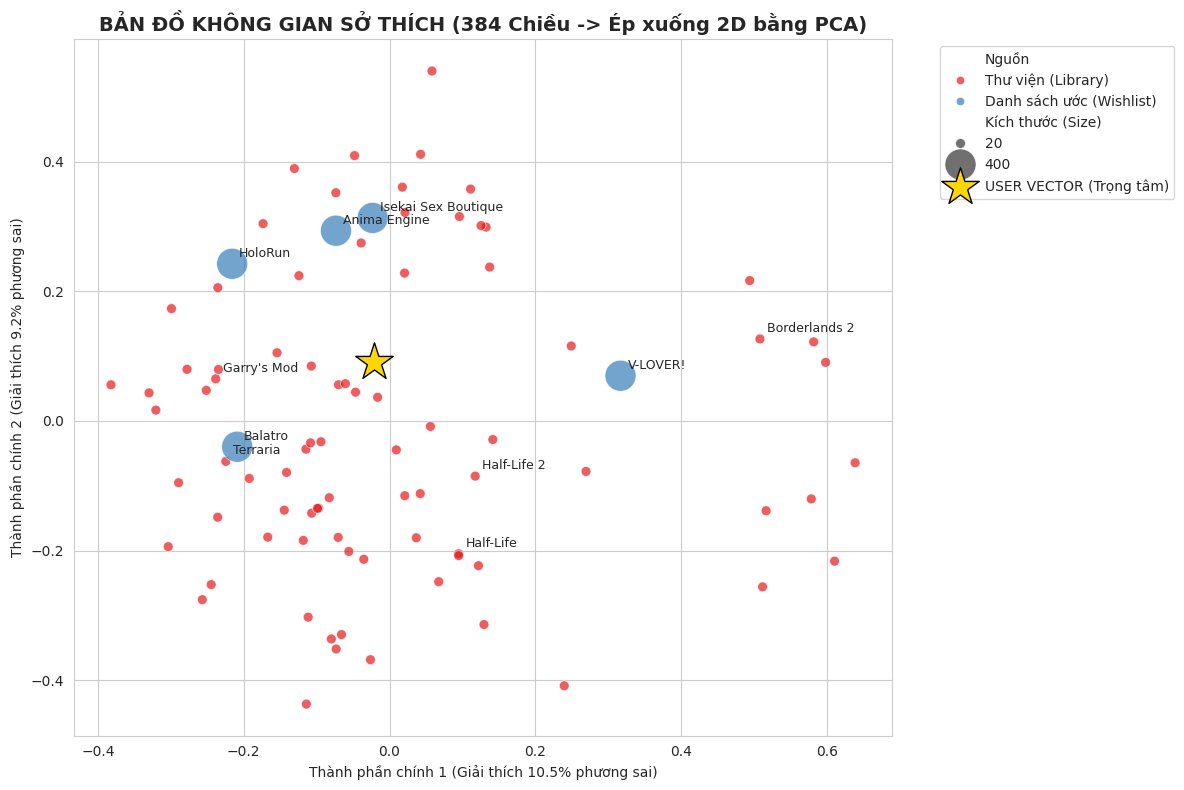

In [ ]:
# ====================================================================================
# CELL 5 (NÂNG CẤP): GIẢI PHẪU LỚP EMBEDDING VÀ TRỰC QUAN HÓA BẰNG PCA
# ====================================================================================

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

test_user_id = "76561199241018614"
author_id_str = str(test_user_id)

print("="*100)
print("BẢNG ĐIỀU KHIỂN CHUYÊN SÂU: GIẢI PHẪU EMBEDDING & PCA".center(100))
print("="*100)

# --- (Phần 1: Lấy dữ liệu giữ nguyên như cũ) ---
wishlist_appids = get_entire_wishlist(author_id_str)
library_data = get_entire_library(author_id_str)
all_library_appids = list(library_data.keys())
all_ids = list(set(all_library_appids + wishlist_appids))
all_ids_str = ", ".join([f"'{x}'" for x in all_ids])

try:
    query_text = f"SELECT CAST(appid AS VARCHAR) as appid, name, genres, categories FROM read_parquet('{GAME_API_PATH}') WHERE CAST(appid AS VARCHAR) IN ({all_ids_str})"
    raw_text_df = con.execute(query_text).df()
    game_meta_dict = {str(row['appid']): {'name': row['name'], 'text': clean_game_text(row['name'] or "", row['genres'] or "", row['categories'] or "")} for _, row in raw_text_df.iterrows()}
except:
    game_meta_dict = {}

unique_texts, weights_list, game_names, sources = [], [], [], []

for aid in all_library_appids:
    if aid in game_meta_dict:
        pt_hours = round(library_data.get(aid, 0) / 60, 2)
        w = 1 if pt_hours <= 0 else min(int(np.log1p(pt_hours) * 2) + 2, 9)
        unique_texts.append(game_meta_dict[aid]['text'])
        weights_list.append(w)
        game_names.append(game_meta_dict[aid]['name'])
        sources.append('Thư viện (Library)')

for aid in wishlist_appids:
    if aid in game_meta_dict:
        unique_texts.append(game_meta_dict[aid]['text'])
        weights_list.append(20) # Trọng số ép cực mạnh cho Wishlist
        game_names.append(game_meta_dict[aid]['name'])
        sources.append('Danh sách ước (Wishlist)')

# =========================================================
# 1. MỔ XẺ MA TRẬN VECTOR (384 CHIỀU)
# =========================================================
if unique_texts:
    u_embs = nlp_model.encode(unique_texts, normalize_embeddings=True, batch_size=32)
    weights_array = np.array(weights_list).reshape(-1, 1)

    user_vector = np.sum(u_embs * weights_array, axis=0) / np.sum(weights_array)
    user_vector = user_vector.reshape(1, -1)

    print("\n[1] SOI CẤU TRÚC VECTOR (5 CHIỀU ĐẦU TIÊN TRÊN TỔNG SỐ 384 CHIỀU):")
    print(f"Hình dáng Ma trận của các Game: {u_embs.shape} (Có {u_embs.shape[0]} game, mỗi game {u_embs.shape[1]} chiều)")
    print(f"Hình dáng Ma trận của User: {user_vector.shape}")

    print("\n=> Vector của Game 1 ({}): \n   {}".format(game_names[0], u_embs[0][:5]))
    print("=> Vector của User (Đã nhân trọng số): \n   {}".format(user_vector[0][:5]))

    # =========================================================
    # 2. ÉP PHẲNG KHÔNG GIAN BẰNG PCA (XUỐNG 2D) VÀ VẼ BIỂU ĐỒ
    # =========================================================
    print("\n[2] ĐANG CHẠY THUẬT TOÁN PCA ĐỂ TRỰC QUAN HÓA KHÔNG GIAN SỞ THÍCH...")

    # Gộp tất cả vector lại (Các Game + User Vector) để fit PCA
    all_vectors = np.vstack([u_embs, user_vector])

    # Dùng PCA giảm từ 384 chiều xuống còn 2 chiều (X và Y)
    pca = PCA(n_components=2, random_state=42)
    vectors_2d = pca.fit_transform(all_vectors)

    # Tách dữ liệu 2D ra lại
    games_2d = vectors_2d[:-1]
    user_2d = vectors_2d[-1]

    # Chuẩn bị dữ liệu để vẽ
    df_plot = pd.DataFrame(games_2d, columns=['PCA_X', 'PCA_Y'])
    df_plot['Tên Game'] = game_names
    df_plot['Trọng số'] = weights_list
    df_plot['Nguồn'] = sources

    # Thiết lập kích thước chấm tỷ lệ thuận với Trọng số (Weight)
    df_plot['Kích thước (Size)'] = df_plot['Trọng số'] * 20

    # BẮT ĐẦU VẼ BẰNG MATPLOTLIB & SEABORN
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    # Vẽ các Game
    sns.scatterplot(data=df_plot, x='PCA_X', y='PCA_Y', hue='Nguồn',
                    size='Kích thước (Size)', sizes=(50, 500), palette='Set1', alpha=0.7)

    # Vẽ User Vector (Trọng tâm) bằng một ngôi sao lớn
    plt.scatter(user_2d[0], user_2d[1], color='gold', marker='*', s=800, edgecolor='black', label='USER VECTOR (Trọng tâm)')

    # Gắn tên cho một vài game nổi bật (tránh gắn hết bị đè chữ)
    top_games_to_annotate = df_plot.sort_values('Trọng số', ascending=False).head(10)
    for i, row in top_games_to_annotate.iterrows():
        plt.annotate(row['Tên Game'], (row['PCA_X'], row['PCA_Y']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    plt.title("BẢN ĐỒ KHÔNG GIAN SỞ THÍCH (384 Chiều -> Ép xuống 2D bằng PCA)", fontsize=14, fontweight='bold')
    plt.xlabel(f"Thành phần chính 1 (Giải thích {pca.explained_variance_ratio_[0]*100:.1f}% phương sai)")
    plt.ylabel(f"Thành phần chính 2 (Giải thích {pca.explained_variance_ratio_[1]*100:.1f}% phương sai)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Hiển thị biểu đồ ngay trên Colab
    plt.show()

else:
    print("Không có dữ liệu để tạo Vector.")

#Trien khai thuc te


In [ ]:
!pip install fastapi uvicorn nest-asyncio
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦
added 22 packages in 842ms
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [ ]:
!fuser -k 8000/tcp

In [ ]:
# ====================================================================================
# CELL 4: MÁY CHỦ FASTAPI (SỬ DỤNG BOOLEAN NATIVE & TỐI ƯU LOCALTUNNEL)
# ====================================================================================

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List
import nest_asyncio
import uvicorn
import threading
import pandas as pd
import numpy as np
import subprocess
import urllib.request
import time

nest_asyncio.apply()

class GameResult(BaseModel):
    name: str
    steam_link: str
    match_probability: float

class APIResponse(BaseModel):
    status: str
    message: str = ""
    results: List[GameResult] = []

app = FastAPI(title="Steam Hybrid AI API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.get("/")
def read_root():
    return {"message": "Server AI Recommendation đang hoạt động tuyệt vời!"}

# [SỬA ĐỔI]: Khai báo nsfw là bool = True. FastAPI sẽ tự động hiểu chữ "true"/"false" từ JS
@app.get("/api/recommend", response_model=APIResponse)
def get_api_recommendations(user_id: str = "", query: str = "", top_k: int = 10, exclude: str = "", nsfw: bool = True):
    if not user_id and not query:
        return {"status": "error", "message": "Vui lòng nhập Steam ID hoặc Thể loại bạn muốn!", "results": []}

    try:
        exclude_list = [x.strip() for x in exclude.split(",") if x.strip()]

        # IN LOG KIỂM TRA TÍN HIỆU BOOLEAN
        print(f"\n[YÊU CẦU API] ID: {user_id} | Lấy: {top_k} Game | Chặn: {len(exclude_list)} Game cũ | Lọc 18+: {nsfw}")

        half_k = max(1, top_k // 2)
        old_k = half_k + (top_k % 2)
        new_k = half_k

        # Truyền TRỰC TIẾP biến nsfw (đã là True/False) vào hàm Lõi AI
        ai_results = get_perfect_hybrid_recommendation(
            author_id=user_id,
            custom_query=query,
            top_k=old_k,
            new_games_k=new_k,
            session_exclude=exclude_list,
            filter_nsfw=nsfw
        )

        final_games_list = []
        def process_dataframe(df):
            if df is None or df.empty: return
            for index, row in df.iterrows():
                prob_val = row.get('match_probability', 0)
                clean_prob = 0.0 if pd.isna(prob_val) or np.isinf(prob_val) else float(prob_val)
                final_games_list.append({
                    "name": str(row.get('name', 'Unknown Game')),
                    "steam_link": str(row.get('steam_link', '')),
                    "match_probability": clean_prob
                })

        process_dataframe(ai_results.get('catalog'))
        process_dataframe(ai_results.get('trending'))

        final_games_list = sorted(final_games_list, key=lambda x: x['match_probability'], reverse=True)

        return {
            "status": "success",
            "message": "Phân tích thành công!",
            "results": final_games_list
        }

    except Exception as e:
        import traceback
        print(f"\n[LỖI SẬP SERVER]:\n{traceback.format_exc()}")
        return {"status": "error", "message": "Đã xảy ra lỗi hệ thống", "results": []}

# ---------------------------------------------------------
# 3. KHỞI ĐỘNG HỆ THỐNG MẠNG VÀ SERVER
# ---------------------------------------------------------
try:
    ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
    print("="*70)
    print(f"IP XÁC THỰC CỦA BẠN LÀ: {ip}  <--- (DÙNG ĐỂ XÁC THỰC LOCALTUNNEL MỚI)")
    print("="*70)
except:
    pass

# Hàm chạy Uvicorn Server ngầm
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

threading.Thread(target=run_server, daemon=True).start()
time.sleep(2)

print("\nĐang tạo đường hầm mạng. Hãy click vào link hiện ra bên dưới!")
!npx localtunnel --port 8000

IP XÁC THỰC CỦA BẠN LÀ: 8.228.4.96  <--- (DÙNG ĐỂ XÁC THỰC LOCALTUNNEL MỚI)

Đang tạo đường hầm mạng. Hãy click vào link hiện ra bên dưới!
⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
^C
